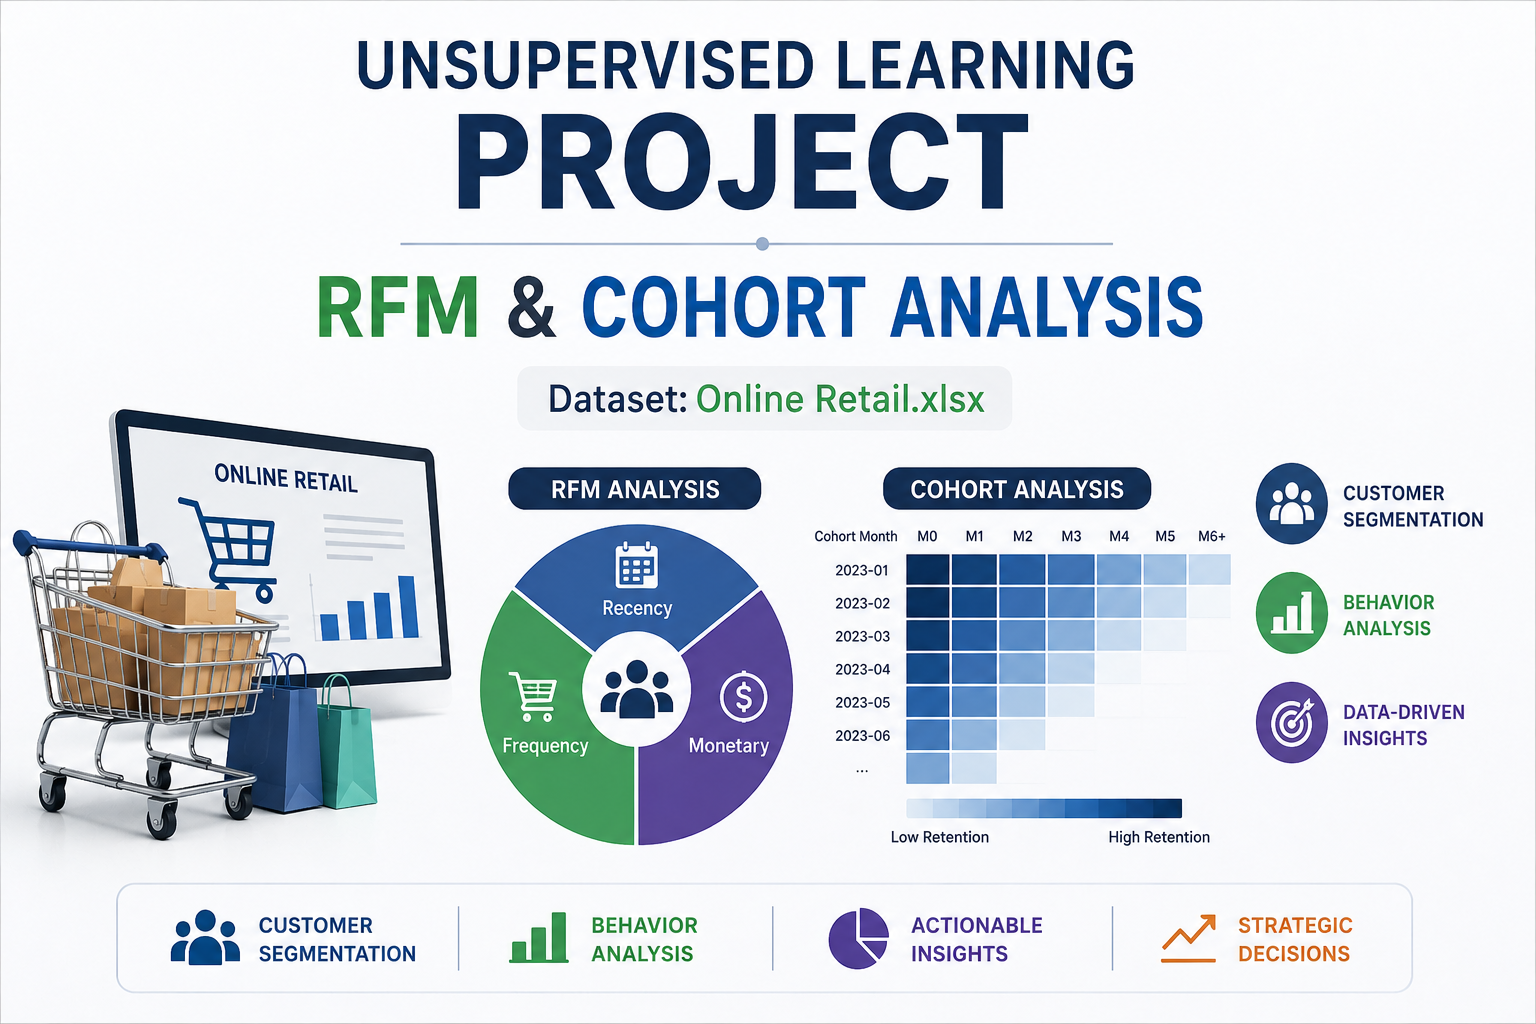

**1. Proje Tanıtımı**
Bu proje, İngiltere merkezli bir çevrimiçi perakende verisini analiz ederek müşteri davranışlarını anlamayı ve iş stratejileri geliştirmeyi amaçlamaktadır. Proje, aşağıdaki adımları içerir:
- Veri temizleme ve keşifsel veri analizi (**Exploratory Data Analysis - EDA**).
- **RFM Analysis** ile müşteri segmentasyonu.
- **K-Means Clustering** kullanarak müşteri segmentasyonu.
- **Cohort Analysis** ile müşteri tutma oranlarının analizi.

---

**2. Veri Seti Bilgisi**
**Veri Seti Özellikleri:**
- **InvoiceNo**: Fatura numarası (6 haneli, her işlem için benzersiz).
- **StockCode**: Ürün veya stok kodu (5 haneli, her ürün için benzersiz).
- **Description**: Ürün açıklaması.
- **Quantity**: Satılan ürün miktarı.
- **InvoiceDate**: Fatura tarihi ve saati.
- **UnitPrice**: Ürün birim fiyatı (sterlin).
- **CustomerID**: Müşteri numarası (5 haneli).
- **Country**: Müşterinin bulunduğu ülke.

---

**3. Proje Yapısı**
1. **Data Cleaning and Exploratory Data Analysis**
   - Veride eksik değerleri ve gürültüleri tespit etme.
   - Veriyi temizleme ve görselleştirme.
   - Fatura, ürün ve ülke bazında analizler yapma.

2. **RFM Analysis & Customer Segmentation**
   - **Recency** (son satın alma), **Frequency** (satın alma sıklığı) ve **Monetary** (harcama tutarı) değerlerini hesaplama.
   - **RFM Table** oluşturma ve müşterileri segmentlere ayırma.
   - RFM skorlarına dayalı segmentasyon.
   - En iyi müşteriler, kayıp müşteriler gibi kategoriler oluşturma.

4. **K-Means Clustering**
   - Özellik mühendisliği (**Feature Engineering**) ve normalizasyon.
   - Kümeleri belirlemek için **Elbow Method** ve **Silhouette Analysis** yöntemlerini kullanma.
   - Sonuçları görselleştirme.

5. **Cohort Analysis**
   - Satın alma tarihlerini kullanarak müşteri grupları (**cohortlar**) oluşturma.
   - Cohort tablosu ile müşteri tutma oranlarını analiz etme.

---

**5. Çıktılar ve Beklentiler**
- **RFM Analysis**’e dayalı müşteri segmentasyon tablosu.
- **K-Means Clustering** ile görselleştirilmiş müşteri kümeleri.
- **Cohort Analysis** ile müşteri tutma oranlarının görselleştirilmesi.

---

# Import Libraries

In [1]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

import warnings
warnings.filterwarnings('ignore')

# Exploratory Data Analysis

In [2]:
import pandas as pd

online_retail = pd.read_excel("Online Retail.xlsx")
online_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df = online_retail.copy()

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.shape
# Veri setinin temel özellikleri:
# Gözlem Sayısı: 541909 
# Feature sayısı : 8


(541909, 8)

In [6]:
df.info()
# datanı dytpes : datetime64 1 

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [7]:
def column_info(df):
    """
    Generate summary information for each column in the DataFrame.

    Parameters:
    df (DataFrame): Input DataFrame.

    Returns:
    DataFrame: DataFrame containing summary information for each column.
    """
    info = []
    for col in df.columns:
        data_type = df[col].dtype
        count = len(df[col])
        nan_count = df[col].isnull().sum()
        nan_percent = (nan_count / count) * 100 if count > 0 else 0
        unique_count = df[col].nunique()

        if pd.api.types.is_numeric_dtype(df[col]):
            max_value = df[col].max()
            min_value = df[col].min()
            sample_value = df[col].dropna().sample().iloc[0] if count - nan_count > 0 else None
        else:
            sample_value = df[col].dropna().sample().iloc[0] if count - nan_count > 0 else None
            max_value = 'no value'
            min_value = 'no value'

        info.append({
            'Column_name': col,
            'Data_Type': data_type,
            'Count': count,
            'NaN_Count': nan_count,
            'NaN_Percent': nan_percent,
            'Unique_Count': unique_count,
            'Max_Value': max_value,
            'Min_Value': min_value,
            'Sample_Value': sample_value
        })

    return pd.DataFrame(info)

In [8]:
column_info(df)

# Online Retail veri seti toplam 541.909 gözlem ve 8 değişkenden oluşmaktadır. Veri setinde işlem bilgileri, ürün detayları, müşteri bilgileri ve işlem tarihleri yer almaktadır.
# Değişkenlerin veri tipleri incelendiğinde; 3 tane object, 1int, 2 float , country str, işlem tarihinin ise datetime formatında tutulduğu görülmektedir.

# Eksik değer analizi sonucunda, Description değişkeninde 1.454 adet (%0,27), CustomerID değişkeninde ise 135.080 adet (%24,93) eksik değer bulunduğu tespit edilmiştir. 
# Literatür taraması sonucunda özellikle CustomerID değişkenindeki yüksek eksik oranı, müşteri bazlı analizlerde dikkate alınması gereken önemli bir veri kalitesi problemine 
# işaret edebileceği söylenebilir. 

# InvoiceNo değişkeninde 25.900 benzersiz fatura numarası bulunurken, StockCode değişkeninde 4.070 farklı ürün kodu yer almaktadır. Bu durum veri setinin geniş bir ürün yelpazesini
# ve çok sayıda işlemi kapsadığını göstermektedir. Ürün açıklamalarını içeren Description değişkeninde ise 4.223 farklı ürün tanımı bulunmaktadır.
 
# Sayısal değişkenler incelendiğinde, Quantity değişkeninin minimum değerinin -80.995, maksimum değerinin ise 80.995 olduğu görülmektedir. 
# Negatif miktar değerleri veri setinde iade veya iptal işlemlerinin bulunduğunu göstermektedir.Benzer şekilde, UnitPrice değişkeninde minimum değerin -11.062,06,
# maksimum değerin ise 38.970 olması, bazı kayıtların düzeltme veya özel işlem niteliğinde olabileceğine işaret etmektedir.

# InvoiceDate değişkeninde 23.260 farklı zaman damgası bulunması, işlemlerin farklı tarih ve saatlerde gerçekleştirildiğini göstermektedir. 
# Bu özellik, zaman bazlı analizler ve müşteri davranışlarının dönemsel incelenmesi açısından önemli bir avantaj sağlamaktadır.

# Country değişkeninde 38 farklı ülke bilgisi yer almakta olup örnek değer olarak United Kingdom görülmektedir. 
# Bu durum veri setinin uluslararası müşteri işlemlerini içerdiğini göstermektedir.

,Column_name,Data_Type,Count,NaN_Count,NaN_Percent,Unique_Count,Max_Value,Min_Value,Sample_Value
0,InvoiceNo,object,541909,0,0.000000,25900,no value,no value,560090
1,StockCode,object,541909,0,0.000000,4070,no value,no value,23338
2,Description,object,541909,1454,0.268311,4223,no value,no value,HANGING METAL HEART LANTERN
3,Quantity,int64,541909,0,0.000000,722,80995,-80995,2
4,InvoiceDate,datetime64[us],541909,0,0.000000,23260,no value,no value,2011-08-30 12:02:00
5,UnitPrice,float64,541909,0,0.000000,1630,38970.0,-11062.06,3.29
6,CustomerID,float64,541909,135080,24.926694,4372,18287.0,12346.0,14959.0
7,Country,str,541909,0,0.000000,38,no value,no value,United Kingdom


In [9]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [10]:
def unique_values(df, columns):
    """Prints unique values and their counts for specific columns in the DataFrame."""

    for column_name in columns:
        print(f"Column: {column_name}\n{'-'*30}")
        unique_vals = df[column_name].unique()
        value_counts = df[column_name].value_counts()
        print(f"Unique Values ({len(unique_vals)}): {unique_vals}\n")
        print(f"Value Counts:\n{value_counts}\n{'='*40}\n")

In [11]:
unique_values(df, df.columns)

#cInvoiceNo feature de  ->  Unique Values :  25900 
#cStockCode feature de  ->  Unique Values :  4070 
# Description feature de ->  Unique Values : 4224 
# Quantity feature de   ->  Unique Values : 722 
# InvoiceDate feature de  ->  Unique Values : 23260
# UnitPrice feature de  ->  Unique Values :  1630
# CustomerID feature de   ->  Unique Values : 4373
# Country feature de  ->  Unique Values : 38

Column: InvoiceNo
------------------------------
Unique Values (25900): [536365 536366 536367 ... 581585 581586 581587]

Value Counts:
InvoiceNo
573585     1114
581219      749
581492      731
580729      721
558475      705
           ... 
581487        1
581491        1
C581499       1
581566        1
C581568       1
Name: count, Length: 25900, dtype: int64

Column: StockCode
------------------------------
Unique Values (4070): ['85123A' 71053 '84406B' ... '90214U' '47591b' 23843]

Value Counts:
StockCode
85123A    2313
22423     2203
85099B    2159
47566     1727
20725     1639
          ... 
23609        1
85179a       1
23617        1
90214U       1
47591b       1
Name: count, Length: 4070, dtype: int64

Column: Description
------------------------------
Unique Values (4224): ['WHITE HANGING HEART T-LIGHT HOLDER' 'WHITE METAL LANTERN'
 'CREAM CUPID HEARTS COAT HANGER' ... 'lost'
 'CREAM HANGING HEART T-LIGHT HOLDER' 'PAPER CRAFT , LITTLE BIRDIE']

Value Counts:
Description
WHITE H

In [12]:
df.isnull().sum() 
# featurelerdeki missing value değerlerinin toplamını verir .Description feature de 1454,CustomerID feature de 135080 missing value (NaN) değeri vardır. 

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

<Axes: >

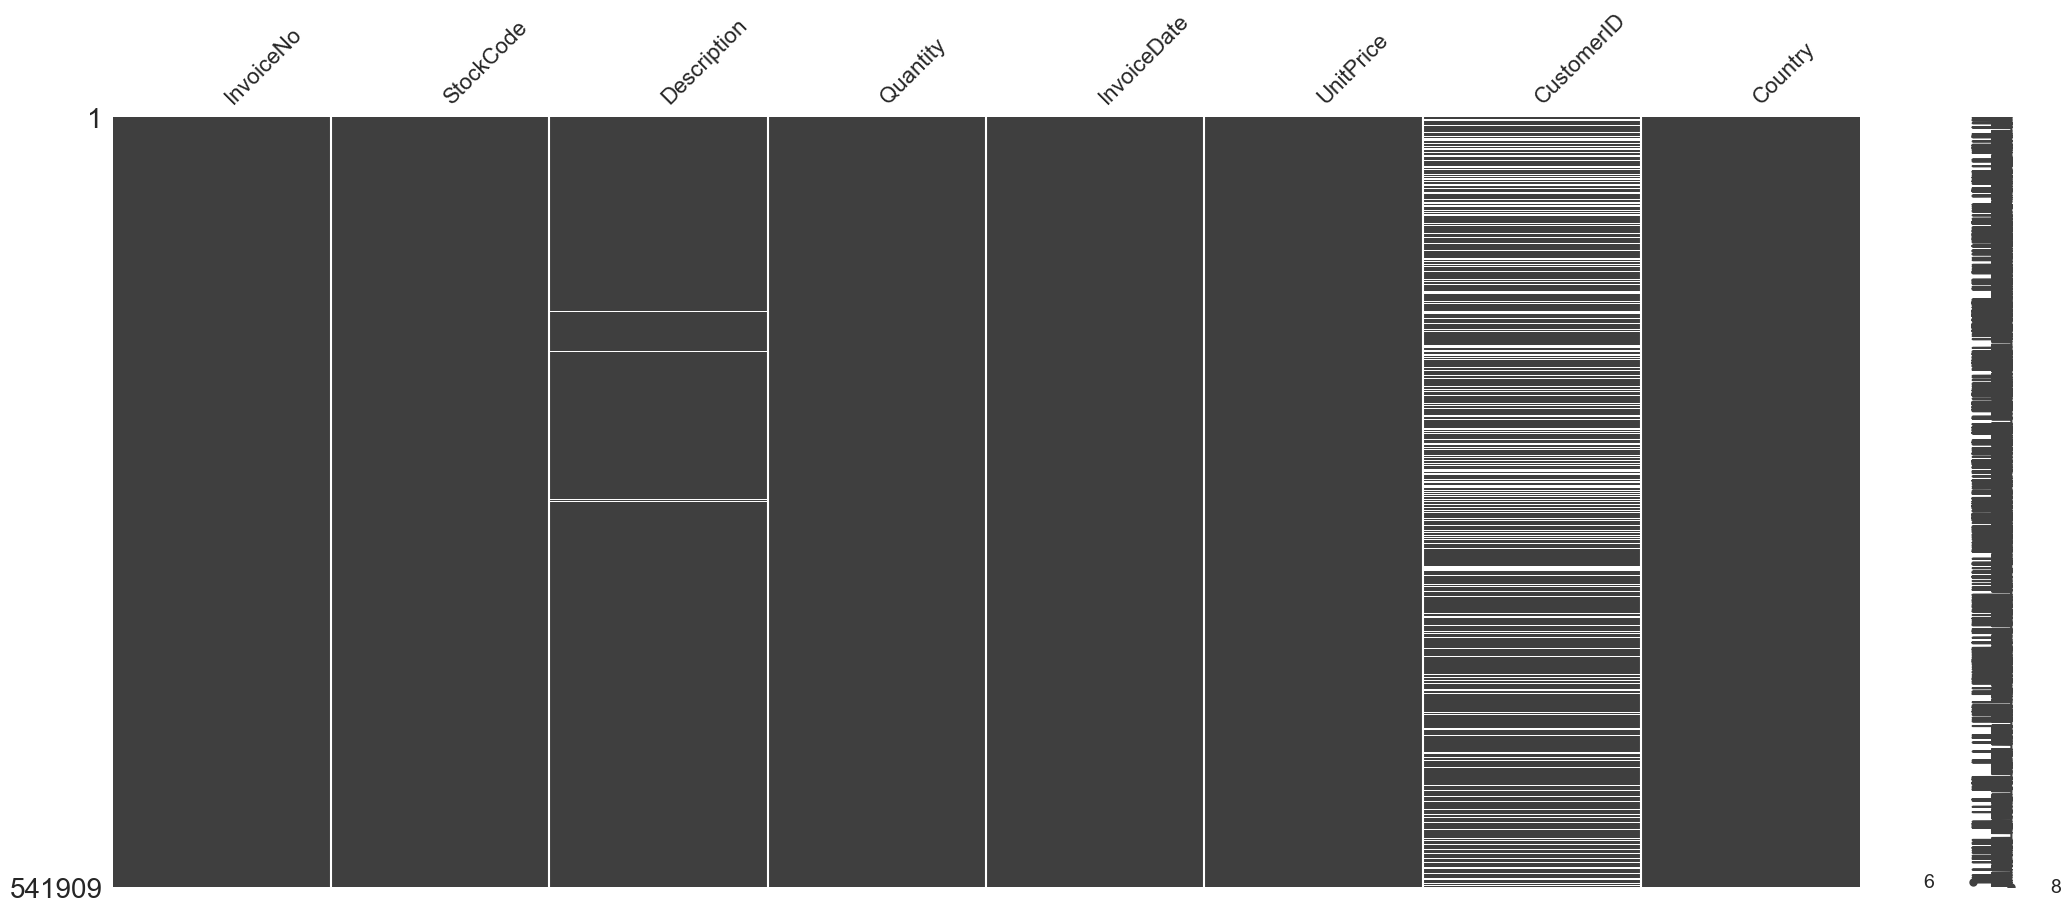

In [13]:
import missingno as msno
msno.matrix(df)

In [14]:
df= df.dropna(subset=['CustomerID'])
# CustomerID değeri boş (NaN) olan satırları veri setinden tamamen çıkarır

<Axes: >

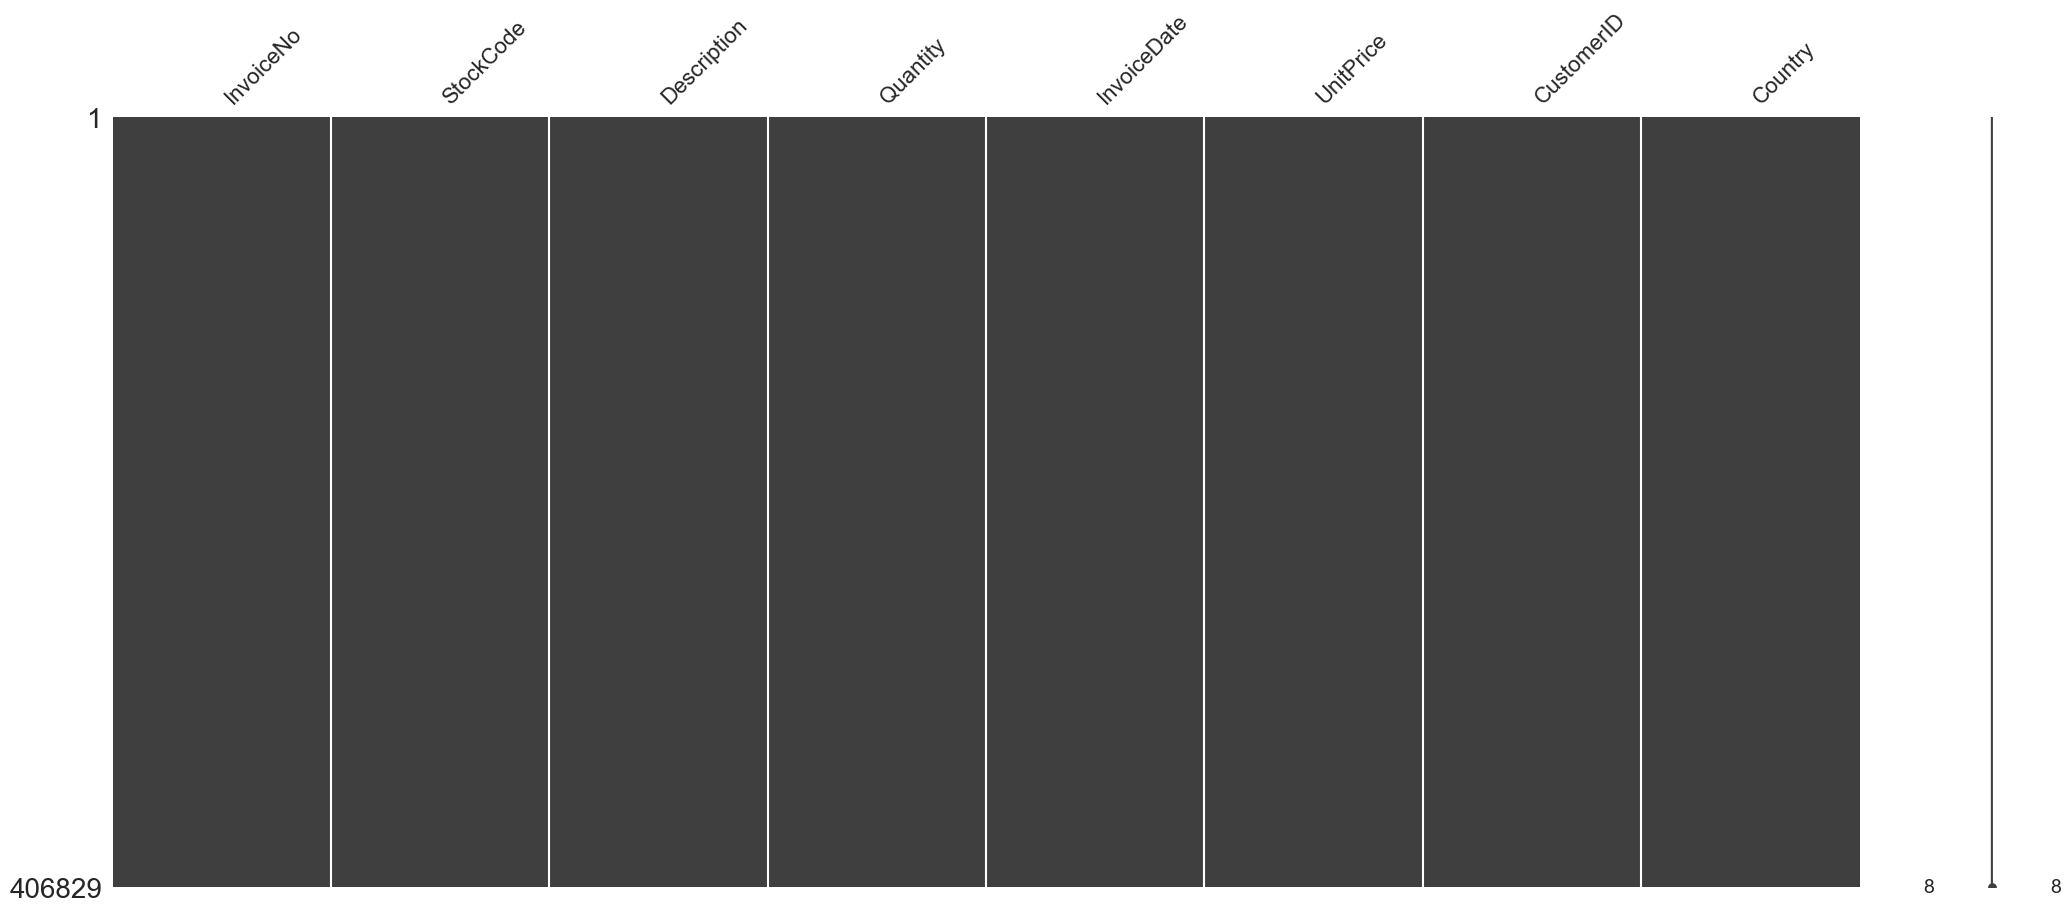

In [15]:
import missingno as msno
msno.matrix(df)

In [16]:
df.isnull().sum()
# CustomerID değeri boş (NaN) olan satırları veri setinden tamamen çıkarıldığı için Description featurede mevcut olan 1454 NaN değerler otomatik olarak silindi

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [17]:
df.duplicated().sum() 
# veri setinde 5225 tane duplicate kayıt vardır

np.int64(5225)

In [18]:
df = df.drop_duplicates() 
# veri setinde 5225 tane duplicate kayıt silinir 

In [19]:
df.duplicated().sum() 

np.int64(0)

In [20]:
df.describe(include="number").T
#Veri setindeki sayısal değişkenler (Quantity, UnitPrice, CustomerID) temel istatistiksel ölçüler açısından incelenmiştir

# Quantity (Satış Miktarı) : Quantity değişkeni ortalama 12.18 iken medyan değeri 5’tir. Bu durum dağılımın sağa çarpık (positively skewed) olduğunu göstermektedir.
   # Minimum değer: -80995
   # Maksimum değer: 80995
   # Negatif değerler, büyük olasılıkla iade (return) işlemlerini temsil etmektedir.
   # Ayrıca çok yüksek maksimum değerler, veri setinde aykırı değerlerin (outliers) bulunduğunu göstermektedir.Bu nedenle Quantity değişkeni oldukça dengesiz ve uç değerlere 
   #duyarlı bir dağılıma sahiptir.

#UnitPrice (Birim Fiyat): UnitPrice değişkeninin ortalama değeri 3.47, medyan değeri ise 1.95’tir. Bu fark, veri dağılımının yine sağa çarpık olduğunu göstermektedir.
   # Minimum değer: 0
   # Maksimum değer: 38970
   #Sıfır fiyatlı ürünler promosyon veya veri hatası olabilirken, çok yüksek maksimum değerler aykırı gözlemler içermektedir.
   # Genel olarak fiyatların büyük kısmı düşük değerlerde yoğunlaşmış, ancak uç değerler ortalamayı yukarı çekmiştir.

# CustomerID : CustomerID değişkeni teknik olarak sayısal görünse de aslında kategorik bir kimlik değişkenidir ve müşteri bazlı analizlerde gruplama amacıyla kullanılmaktadır.
   # Minimum: 12346
   # Maksimum: 18287
   # Standart sapma: 1714
   #Bu dağılım, veri setinde geniş bir müşteri kitlesi bulunduğunu göstermektedir.Ancak bu değişken istatistiksel anlamda bir büyüklük ifade etmediği için modelleme 
   # aşamasında numerik bir değişken olarak yorumlanmamalıdır.

,count,mean,std,min,25%,50%,75%,max
Quantity,401604.0,12.183273,250.283037,-80995.0,2.00,5.00,12.00,80995.0
UnitPrice,401604.0,3.474064,69.764035,0.0,1.25,1.95,3.75,38970.0
CustomerID,401604.0,15281.160818,1714.006089,12346.0,13939.00,15145.00,16784.00,18287.0


In [21]:
# InvoiceNo featuresindeki verilerin dağılımı 
# Toplam sipariş sayısı
total_orders = len(df)

# İptal edilen siparişler (C ile başlayanlar)
canceled_orders = df['InvoiceNo'].astype(str).str.startswith('C', na=False).sum()

# Normal siparişler
normal_orders = total_orders - canceled_orders

summary = pd.DataFrame({
    "Type": ["Total Orders", "Canceled Orders", "Normal Orders"],
    "Count": [total_orders, canceled_orders, normal_orders]
})

print(summary)

              Type   Count
0     Total Orders  401604
1  Canceled Orders    8872
2    Normal Orders  392732


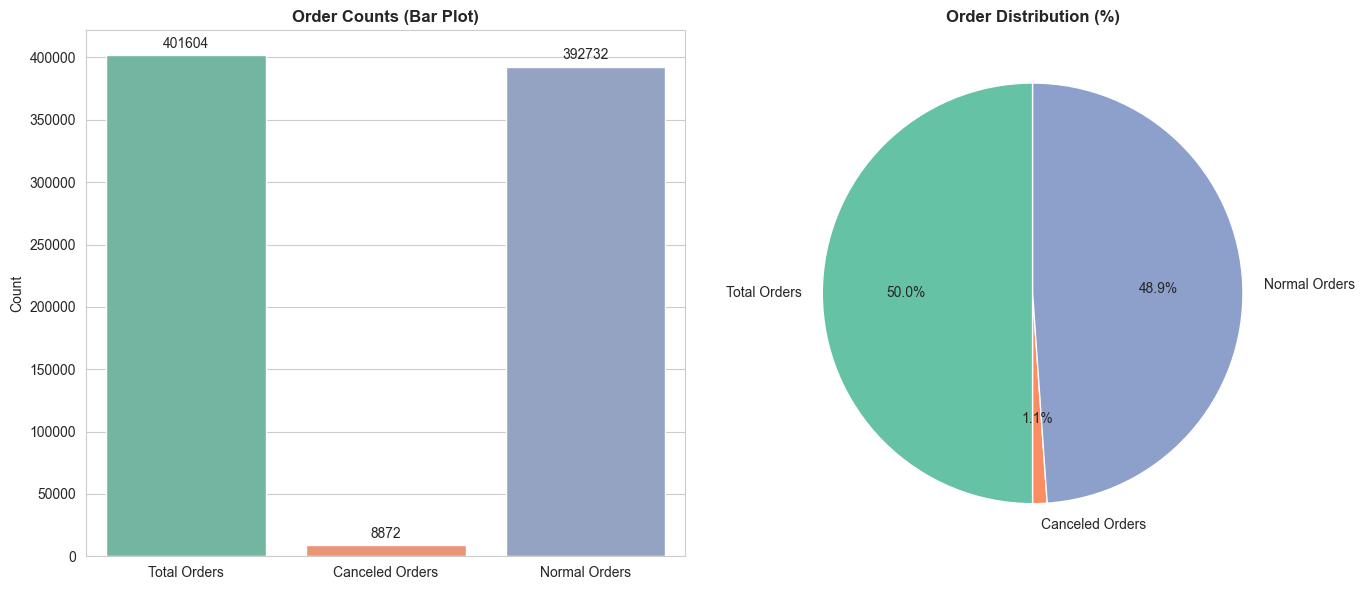

In [22]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. BAR PLOT (InvoiceNo featuresindeki verilerin dağılımı gösteren grafik ) 
# -------------------------
sns.barplot(data=summary, x="Type", y="Count", ax=axes[0], palette="Set2")

axes[0].set_title("Order Counts (Bar Plot)", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=0)
for container in axes[0].containers: axes[0].bar_label(container, fmt='%d', padding=3)
# -------------------------
# 2. PIE CHART (InvoiceNo featuresindeki verilerin % dağılımı gösteren grafik ) 
# -------------------------
axes[1].pie( summary["Count"], labels=summary["Type"], autopct="%1.1f%%", startangle=90, colors=["#66c2a5", "#fc8d62", "#8da0cb"])

axes[1].set_title("Order Distribution (%)", fontweight="bold")

plt.tight_layout()
plt.show()

In [23]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')] # C ile başlayanları filtreleyip veriden çıkarır

In [24]:
# Toplam kayıt sayısı
total_records = len(df)

# Quantity <= 0 olanlar
quantity_non_positive = (df['Quantity'] <= 0).sum() # Negatif Quantity → iade/iptal işlemleri, Sıfır Quantity → veri hatası veya geçersiz kayıt

# UnitPrice <= 0 olanlar
unitprice_non_positive = (df['UnitPrice'] <= 0).sum() # UnitPrice = 0 UnitPrice < 0 : Bunlar genellikle:Ücretsiz ürünler,Veri giriş hataları,Geçersiz fiyat kayıtları

# Her iki koşulu da sağlayanlar
both_non_positive = ((df['Quantity'] <= 0) & (df['UnitPrice'] <= 0)).sum()

summary = pd.DataFrame({"Type": [
                                    "Total Records",
                                    "Quantity <= 0",
                                    "UnitPrice <= 0",
                                    "Both Quantity & UnitPrice <= 0"
                                ],
                        "Count": [
                            total_records,
                            quantity_non_positive,
                            unitprice_non_positive,
                            both_non_positive
                        ]
                    })

print(summary)
# Veri kalitesini değerlendirmek amacıyla, iptal edilen siparişler veri setinden çıkarıldıktan sonra
# Quantity ve UnitPrice değişkenleri incelenmiştir.

# Analiz sonucunda Quantity değeri sıfır veya negatif olan herhangi bir kayda rastlanmamıştır.
# Bunun temel nedeni, negatif Quantity değerlerinin büyük ölçüde iptal/iade işlemlerine ait olması
# ve bu kayıtların önceki adımda veri setinden çıkarılmış olmasıdır.

# Buna karşılık UnitPrice değeri sıfır veya negatif olan 40 kayıt tespit edilmiştir.
# Bu kayıtlar ücretsiz ürünler, promosyon ürünleri veya veri giriş hatalarından kaynaklanabilir.

# Quantity ve UnitPrice değerlerinin her ikisinin de sıfır veya negatif olduğu herhangi bir kayıt bulunmamıştır.

# Elde edilen sonuçlar doğrultusunda UnitPrice değeri sıfır veya negatif olan kayıtlar
# veri temizleme aşamasında veri setinden çıkarılacaktır.

                             Type   Count
0                   Total Records  392732
1                   Quantity <= 0       0
2                  UnitPrice <= 0      40
3  Both Quantity & UnitPrice <= 0       0


In [25]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# İptal edilen siparişler veri setinden çıkarıldıktan sonra Quantity ve UnitPrice değişkenleri incelenmiştir. Analiz sonucunda Quantity değeri sıfır veya negatif olan kayıt bulunmazken,
# UnitPrice değeri sıfır olan 40 kayıt tespit edilmiştir. Bu kayıtlar satış tutarı hesaplamalarını etkileyebileceğinden veri setinden çıkarılmış ve analizler yalnızca Quantity > 0 ve
# UnitPrice > 0 koşullarını sağlayan gerçek satış işlemleri üzerinden gerçekleştirilmiştir.

In [26]:
# Toplam harcama (satır bazında işlem tutarı)
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [27]:
df.describe(include="number").T
#Bu veri seti, küçük ölçekli satışların çoğunlukta olduğu ama birkaç aşırı büyük sipariş ve fiyatın ortalamayı ciddi şekilde bozduğu sağa çarpık bir satış dağılımına sahip.

,count,mean,std,min,25%,50%,75%,max
Quantity,392692.0,13.119702,180.492832,1.000,2.00,6.00,12.00,80995.00
UnitPrice,392692.0,3.125914,22.241836,0.001,1.25,1.95,3.75,8142.75
CustomerID,392692.0,15287.843865,1713.539549,12346.000,13955.00,15150.00,16791.00,18287.00
TotalAmount,392692.0,22.631500,311.099224,0.001,4.95,12.45,19.80,168469.60


In [28]:
numeric_columns = ["Quantity", "UnitPrice", "TotalAmount"]

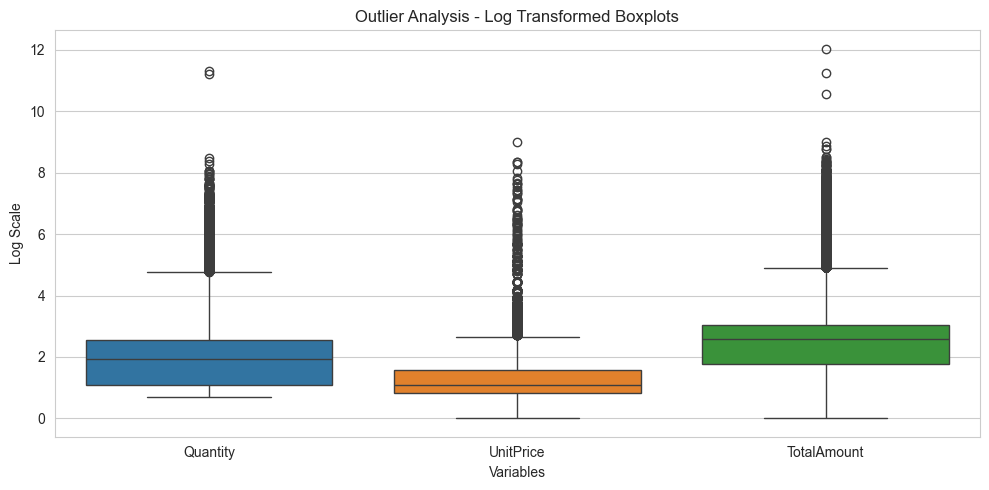

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numeric_columns = ["Quantity", "UnitPrice", "TotalAmount"]

# Log dönüşümü (0 değerleri korumak için log1p)
df_box = df[numeric_columns].apply(np.log1p)

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_box
)

plt.title("Outlier Analysis - Log Transformed Boxplots")
plt.xlabel("Variables")
plt.ylabel("Log Scale")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [30]:
def outlier_summary(dataframe, columns):

    results = []

    for col in columns:

        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = dataframe[(dataframe[col] < lower) |(dataframe[col] > upper)]

        results.append([col, round(lower, 2),round(upper, 2),len(outliers)])

    return pd.DataFrame(results,columns=["Feature", "Lower Bound","Upper Bound","Outlier Count"])

outlier_summary(df,["Quantity","UnitPrice","TotalAmount"])

,Feature,Lower Bound,Upper Bound,Outlier Count
0,Quantity,-13.00,27.00,25616
1,UnitPrice,-2.50,7.50,34112
2,TotalAmount,-17.32,42.08,31231


In [31]:
def outlier_bounds(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

def outlier_ratio(dataframe, column):
    lower_bound, upper_bound = outlier_bounds(dataframe, column)
    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
    return round((len(outliers) / len(dataframe)) * 100,2)
for col in numeric_columns:
    print(f"{col} : %{outlier_ratio(df, col)}")

#IQR yöntemi ile yapılan aykırı değer analizinde Quantity, UnitPrice ve TotalAmount değişkenlerinde önemli sayıda aykırı gözlem tespit edilmiştir.
# Ancak veri seti bir e-ticaret işletmesine ait olduğundan bu gözlemlerin önemli bir kısmının yüksek hacimli veya yüksek değerli gerçek müşteri işlemlerini temsil ettiği değerlendirilmiştir.
#Bu nedenle RFM ve Cohort analizlerinde aykırı değerler veri setinden çıkarılmamış, K-Means kümeleme aşamasında ölçekleme ve dönüşüm teknikleri kullanılarak etkileri azaltılması öngörülmüştür 

Quantity : %6.52
UnitPrice : %8.69
TotalAmount : %7.95


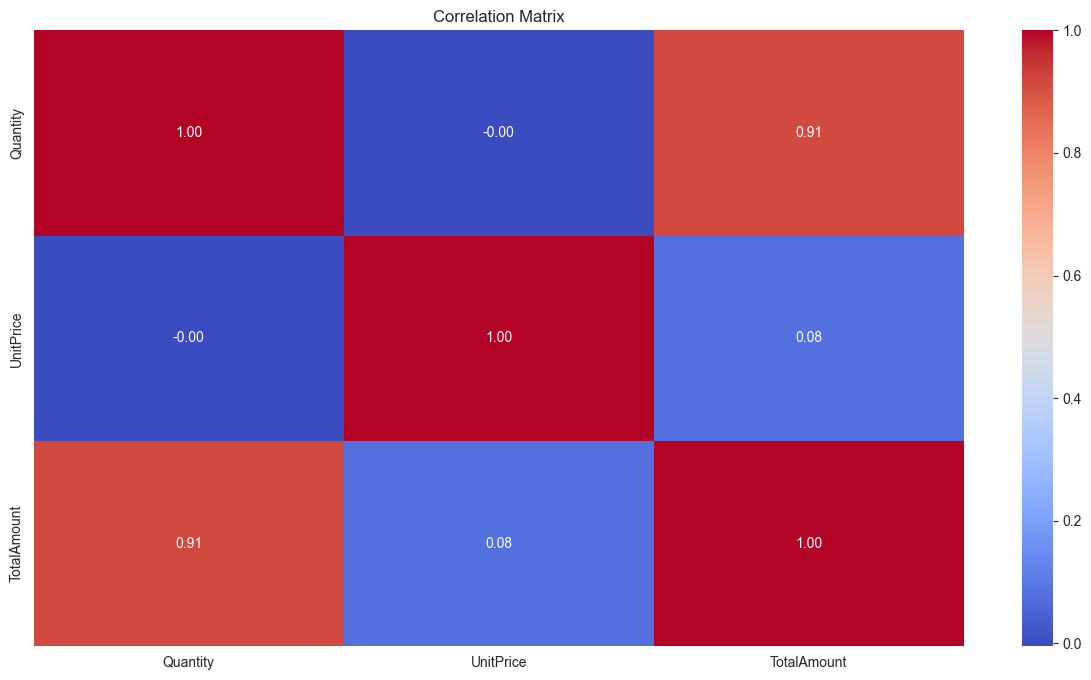

In [33]:

# feature'lar arası korelasyona bakıyoruz

import seaborn as sns
import matplotlib.pyplot as plt

numeric_columns = ["Quantity", "UnitPrice", "TotalAmount"]

plt.figure(figsize=(15,8))

# sadece seçtiğin sütunlar
numeric_df = df[numeric_columns]

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()


In [37]:
df["Country"].value_counts().head(10)

Country
United Kingdom    349203
Germany             9025
France              8326
EIRE                7226
Spain               2479
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1453
Australia           1181
Name: count, dtype: int64

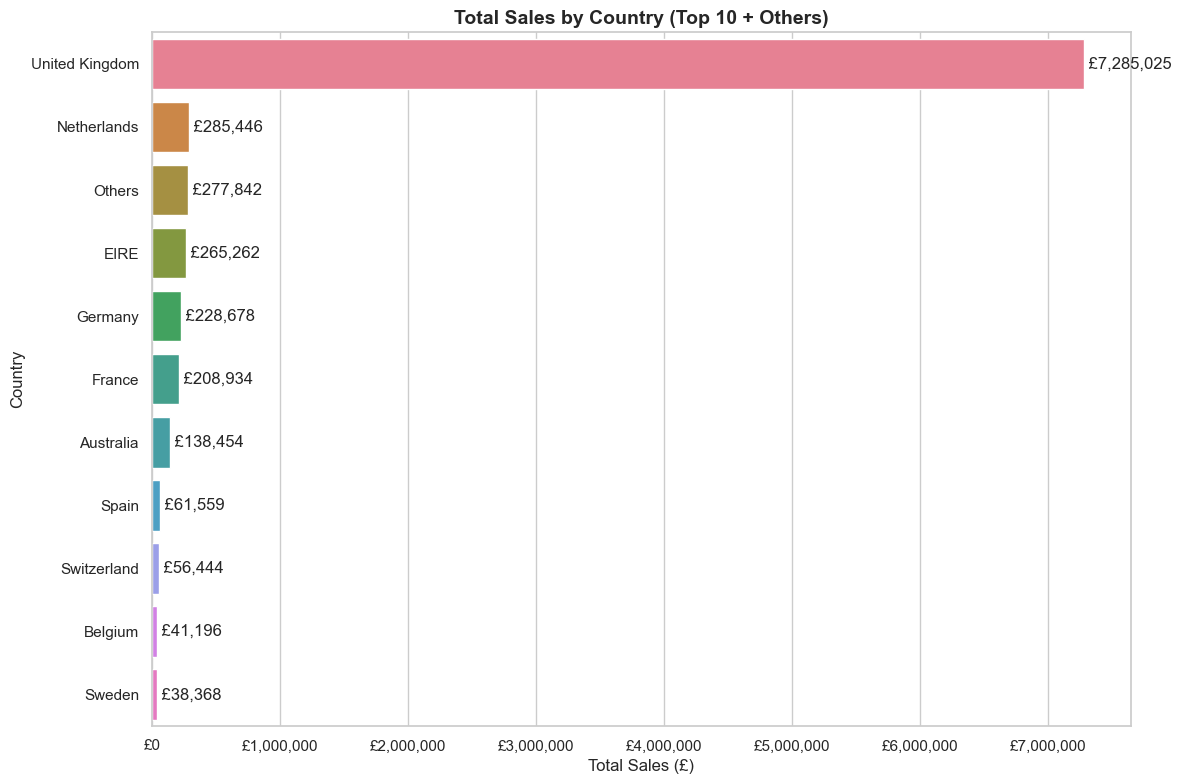

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# Ülke bazlı satış
country_sales = (df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False))

# Top N ülke ()
top_n = 10

top_countries = country_sales[:top_n] # en çok satış yapan 10 ülke 
others = country_sales[top_n:].sum() # satış yapan diğer ülkelerin toplamı 

# Yeni seri
plot_data = top_countries.copy()
plot_data["Others"] = others

plot_data = plot_data.sort_values(ascending=False)

plt.figure(figsize=(12, 8))

ax = sns.barplot( x=plot_data.values, y=plot_data.index, hue=plot_data.index, legend=False)

ax.xaxis.set_major_formatter( mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# bar üstüne değer yazma
for i, value in enumerate(plot_data.values): plt.text(value, i, f' £{value:,.0f}', va='center' )

plt.title("Total Sales by Country (Top 10 + Others)", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales (£)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [ ]:
top_products = (df.groupby("Description").agg({"Quantity":"sum"}).sort_values("Quantity", ascending=False).head(20))

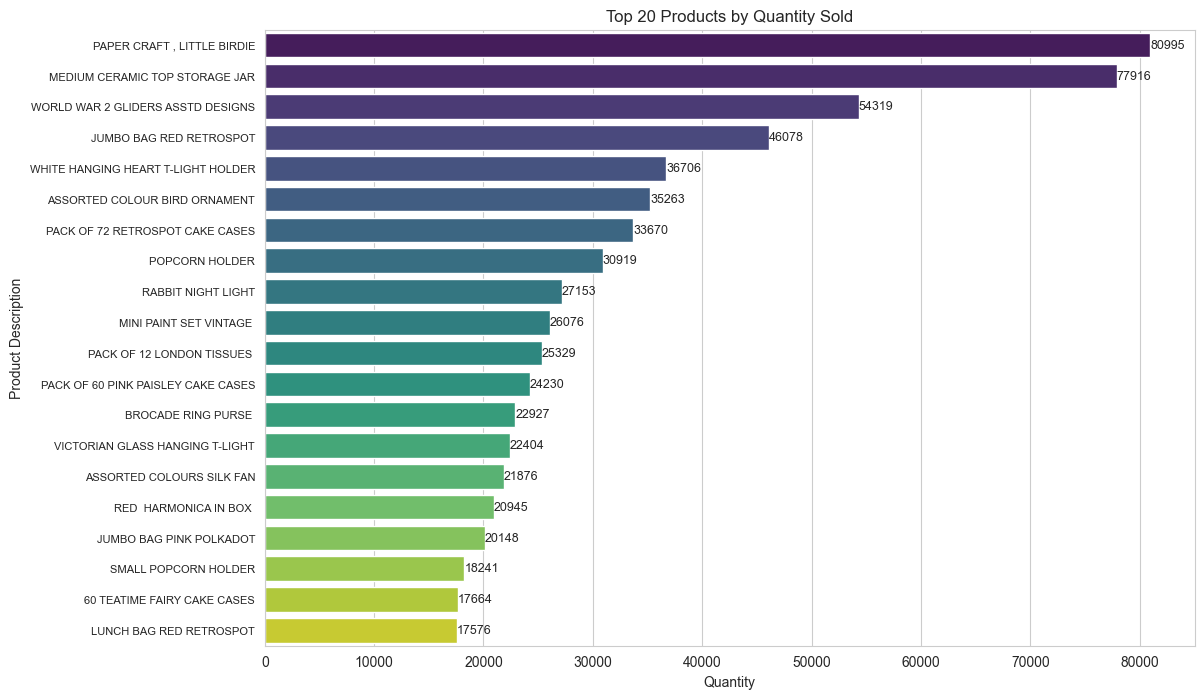

In [40]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

top_products = (df.groupby("Description").agg({"Quantity":"sum"}).sort_values("Quantity", ascending=False).head(20))

ax = sns.barplot( x=top_products["Quantity"],y=top_products.index,palette="viridis")

for i, value in enumerate(top_products["Quantity"]): ax.text(value, i, str(value), va='center', fontsize=9)

plt.title("Top 20 Products by Quantity Sold")
plt.xlabel("Quantity")
plt.ylabel("Product Description")

plt.yticks(fontsize=8)

plt.show()
#En çok satılan 20 ürün

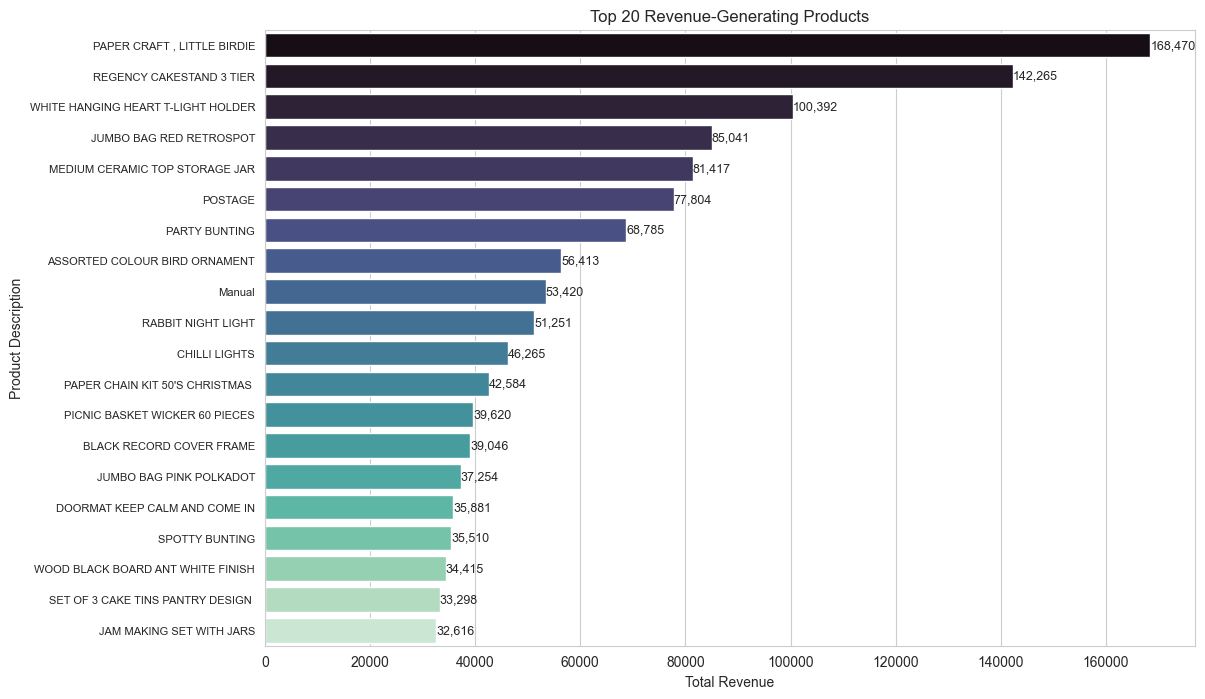

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

top_revenue = (df.groupby("Description")["TotalAmount"].sum().sort_values(ascending=False).head(20))

plt.figure(figsize=(12,8))

ax = sns.barplot(x=top_revenue.values, y=top_revenue.index,palette="mako")

for i, value in enumerate(top_revenue.values): ax.text(value, i, f"{value:,.0f}", va='center', fontsize=9) # bar üstüne yazma 

plt.title("Top 20 Revenue-Generating Products")
plt.xlabel("Total Revenue")
plt.ylabel("Product Description")

plt.yticks(fontsize=8)

plt.show()
# En yüksek gelir getiren 20 ürün 

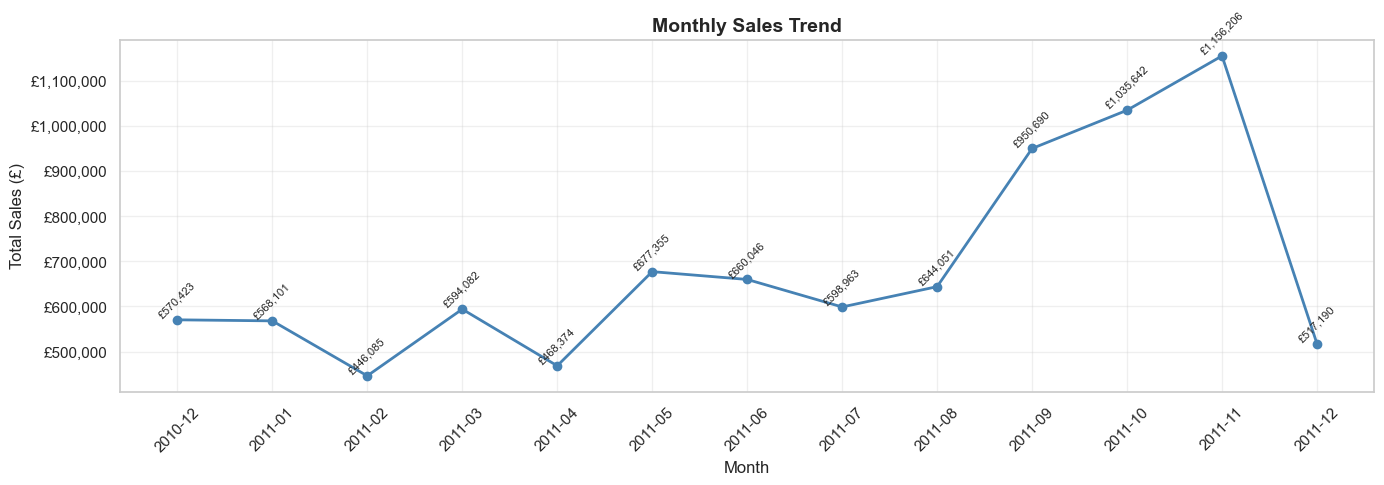

In [139]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Aylık satış trendi
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = ( df.groupby('YearMonth')['TotalAmount'].sum().sort_index())

plt.figure(figsize=(14, 5))

plt.plot( monthly_sales.index.astype(str), monthly_sales.values, marker='o',linewidth=2, color='steelblue')

plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales (£)')

# para formatı
plt.gca().yaxis.set_major_formatter( mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

# nokta üstüne değer yazma
for i, value in enumerate(monthly_sales.values):
    plt.text(i, value,f'£{value:,.0f}', ha='center',va='bottom',fontsize=8,rotation=45    )

plt.tight_layout()
plt.show()
# aylık satış trendi 

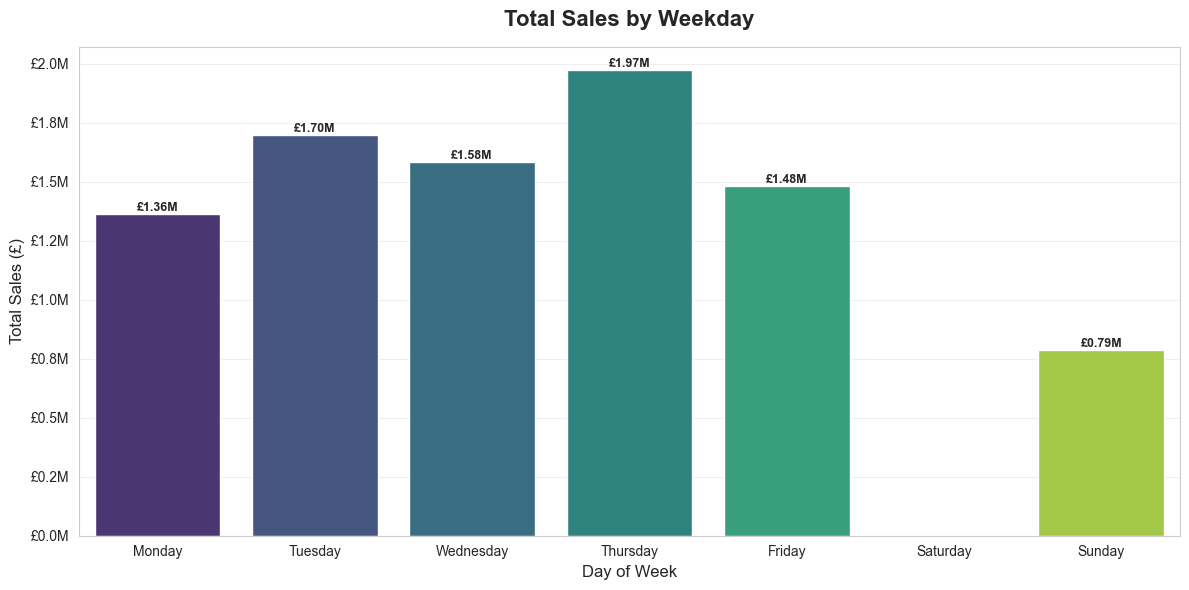

In [49]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Haftanın günü
df["Weekday"] = df["InvoiceDate"].dt.day_name()

weekday_order = [ "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_sales = (df.groupby("Weekday")["TotalAmount"].sum().reindex(weekday_order))

plt.figure(figsize=(12, 6))

ax = sns.barplot(x=weekday_sales.index, y=weekday_sales.values, palette="viridis")

plt.title("Total Sales by Weekday", fontsize=16,fontweight="bold",pad=15)
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Total Sales (£)", fontsize=12)

plt.gca().yaxis.set_major_formatter( mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))

# Bar üstüne değer yaz
for bar in ax.patches:
    value = bar.get_height()

    ax.annotate(
        f'£{value/1e6:.2f}M',
        (bar.get_x() + bar.get_width()/2, value),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
# günlük satış miktarı 

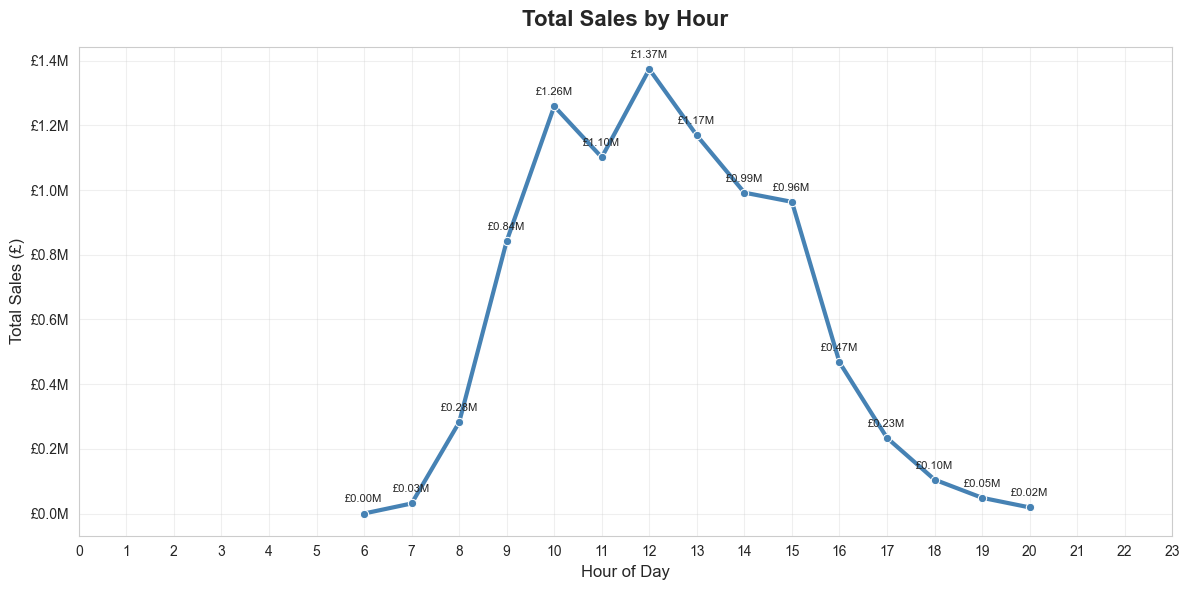

In [50]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Saat bilgisi
df["Hour"] = df["InvoiceDate"].dt.hour

# Saatlik satışlar
hourly_sales = (df.groupby("Hour")["TotalAmount"].sum().sort_index())

plt.figure(figsize=(12,6))

ax = sns.lineplot(x=hourly_sales.index,y=hourly_sales.values,marker="o",linewidth=3,color="steelblue")

plt.title("Total Sales by Hour", fontsize=16, fontweight="bold",pad=15)

plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Total Sales (£)", fontsize=12)

# Y eksenini milyon formatında göster
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))

# Her noktanın üzerine değer yaz
for x, y in zip(hourly_sales.index, hourly_sales.values):
    plt.annotate(
        f'£{y/1e6:.2f}M',
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        fontsize=8
    )

plt.xticks(range(0, 24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
# Saatlik satışlar 

In [51]:
df.to_excel("Online_Retail_Cleaned.xlsx", index=False)

#EDA işlemleri sonunda datayı sıfırdan çalıştırmamak için temizlenmiş datayı kaydederiz. 

In [52]:
df1 = pd.read_excel("Online_Retail_Cleaned.xlsx")
df1.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Month,Weekday,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,Wednesday,8


# RFM Analysis

**RFM Analizi Nedir?**

RFM analizi, müşteri davranışlarını değerlendirmek için kullanılan bir pazarlama teknik ve yöntemidir. 

RFM, Recency (Yenilik), Frequency (Sıklık) ve Monetary (Parasal Değer) kelimelerinin baş harflerinden oluşur.

**RFM bileşenleri:**

- **Recency (Yenilik):** Müşterinin son satın alma işlemini gerçekleştirdiği tarihin ne kadar yakın olduğunu gösterir. Daha yeni satın almış müşteriler, daha yüksek bir recency skoruna sahiptir.
  
- **Frequency (Sıklık):** Müşterinin belirli bir zaman aralığında (genellikle bir yıl içinde) kaç satın alma işlemi gerçekleştirdiğini gösterir. Daha sık alışveriş yapan müşteriler, daha yüksek bir frequency skoruna sahiptir.
  
- **Monetary (Parasal Değer):** Müşterinin belirli bir zaman aralığında harcadığı toplam tutarı ifade eder. Daha yüksek tutarda alışveriş yapan müşteriler, daha yüksek bir monetary skoruna sahiptir.

**RFM Analizi Nasıl Yapılır?**

1. **Müşteri Verisinin Hazırlanması:** İlgili döneme ait müşteri verisi toplanır. Bu veriler genellikle müşteri kimlikleri, satın alma tarihleri ve tutarları içerir.

2. **RFM Skorlarının Hesaplanması:** Her bir müşteri için Recency, Frequency ve Monetary skorları hesaplanır. Bu skorlar genellikle 1 ila 5 arasında bir ölçekte olabilir. Örneğin, 5 en iyi (yani, en yeni, en sık ve en yüksek tutarda) müşteriyi temsil ederken, 1 en kötü müşteriyi temsil eder.

3. **Müşteri Segmentasyonu:** RFM skorlarına göre müşteriler farklı segmentlere ayrılır. Örneğin, RFM skorlarının kombinasyonlarına göre "VIP", "Sadık Müşteri", "Potansiyel Müşteri" gibi segmentler oluşturulabilir.

4. **Pazarlama Stratejilerinin Belirlenmesi:** Her bir müşteri segmenti için uygun pazarlama stratejileri geliştirilir. Örneğin, VIP müşterilere özel indirimler veya sadık müşterilere özel teşvikler sunulabilir.

**RFM Analizinin Faydaları:**

- **Müşteri Segmentasyonu:** RFM analizi, müşterileri farklı gruplara ayırarak pazarlama stratejilerini kişiselleştirmeye olanak tanır.
  
- **Sadık Müşterilerin Tanımlanması:** RFM analizi, sadık müşterileri belirlemek ve onlara özel teşvikler sunmak için kullanılabilir.
  
- **Pazarlama Verimliliğinin Artırılması:** Müşterilerin davranışlarının daha iyi anlaşılması, pazarlama stratejilerinin daha etkili bir şekilde yönetilmesine yardımcı olur.*

In [53]:
# Referans tarihi (veri setindeki son alışveriş tarihinden 1 gün sonrası)
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(f"Analysis Date: {analysis_date.date()}")

# RFM Tablosu
rfm = df.groupby("CustomerID").agg(
                                    Recency=("InvoiceDate", lambda x: (analysis_date - x.max()).days),
                                    Frequency=("InvoiceNo", "nunique"),
                                    Monetary=("TotalAmount", "sum")
                                ).reset_index()

print(f"\nUnique Customer Count: {len(rfm):,}")

rfm.describe().round(2)

Analysis Date: 2011-12-10

Unique Customer Count: 4,338


,CustomerID,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00,4338.00
mean,15300.41,92.54,4.27,2048.69
std,1721.81,100.01,7.70,8985.23
min,12346.00,1.00,1.00,3.75
25%,13813.25,18.00,1.00,306.48
50%,15299.50,51.00,2.00,668.57
75%,16778.75,142.00,5.00,1660.60
max,18287.00,374.00,209.00,280206.02


- RFM Analizi – Genel İstatistikler

- RFM (Recency, Frequency, Monetary) analizi kapsamında toplam 4.338 benzersiz müşteri değerlendirilmiştir. Analiz tarihi olarak veri setindeki son işlem tarihi olan 09.12.2011'in bir gün sonrası olan 10.12.2011 kullanılmıştır.

- Recency (Son Satın Alma Süresi): 
Müşterilerin ortalama son alışveriş süresi 92 gün olarak hesaplanmıştır.
Medyan değer 51 gün olup, müşterilerin yarısının son 51 gün içinde alışveriş yaptığı görülmektedir.
En aktif müşteri analiz tarihinden yalnızca 1 gün önce alışveriş yaparken, bazı müşterilerin son alışverişlerinin üzerinden 374 gün geçtiği belirlenmiştir.
Bu sonuçlar, müşteri kitlesinin bir kısmının oldukça aktif olduğunu, diğer kısmının ise uzun süredir alışveriş yapmadığını göstermektedir.

- Frequency (Satın Alma Sıklığı): 
Müşteriler ortalama 4 farklı sipariş vermiştir.
Medyan değer 2 sipariş olup, müşterilerin büyük çoğunluğunun düşük satın alma sıklığına sahip olduğu görülmektedir.
En yüksek satın alma sıklığına sahip müşteri 209 farklı sipariş gerçekleştirmiştir.
Ortalama ve maksimum değer arasındaki büyük fark, veri setinde yüksek değerli ve sadık müşterilerin bulunduğunu göstermektedir.

- Monetary (Toplam Harcama): 
Müşteri başına ortalama harcama tutarı 2.048,69 £ olarak hesaplanmıştır.
Medyan harcama tutarı 668,57 £ olup ortalamanın oldukça altında kalmaktadır.
En yüksek harcamaya sahip müşteri toplam 280.206,02 £ değerinde alışveriş yapmıştır.
Ortalama ve medyan arasındaki büyük fark ile yüksek standart sapma (8.985,23 £), müşteri harcamalarının homojen dağılmadığını ve az sayıda müşterinin toplam gelirin önemli bir bölümünü oluşturduğunu göstermektedir.

- Genel Değerlendirme: 
RFM değişkenlerinin dağılımları incelendiğinde müşteri davranışlarının heterojen bir yapıya sahip olduğu görülmektedir. Veri setinde hem yüksek harcama yapan ve sık alışveriş gerçekleştiren sadık müşteriler hem de uzun süredir alışveriş yapmayan düşük değerli müşteriler bulunmaktadır. Bu durum, müşteri segmentasyonunun gerekli olduğunu ve RFM analizinin müşterileri farklı değer gruplarına ayırmada etkili bir yöntem olacağını göstermektedir. Bir sonraki aşamada müşteriler RFM skorları kullanılarak segmentlere ayrılmış ve her segment için farklı iş stratejileri geliştirilmiştir.

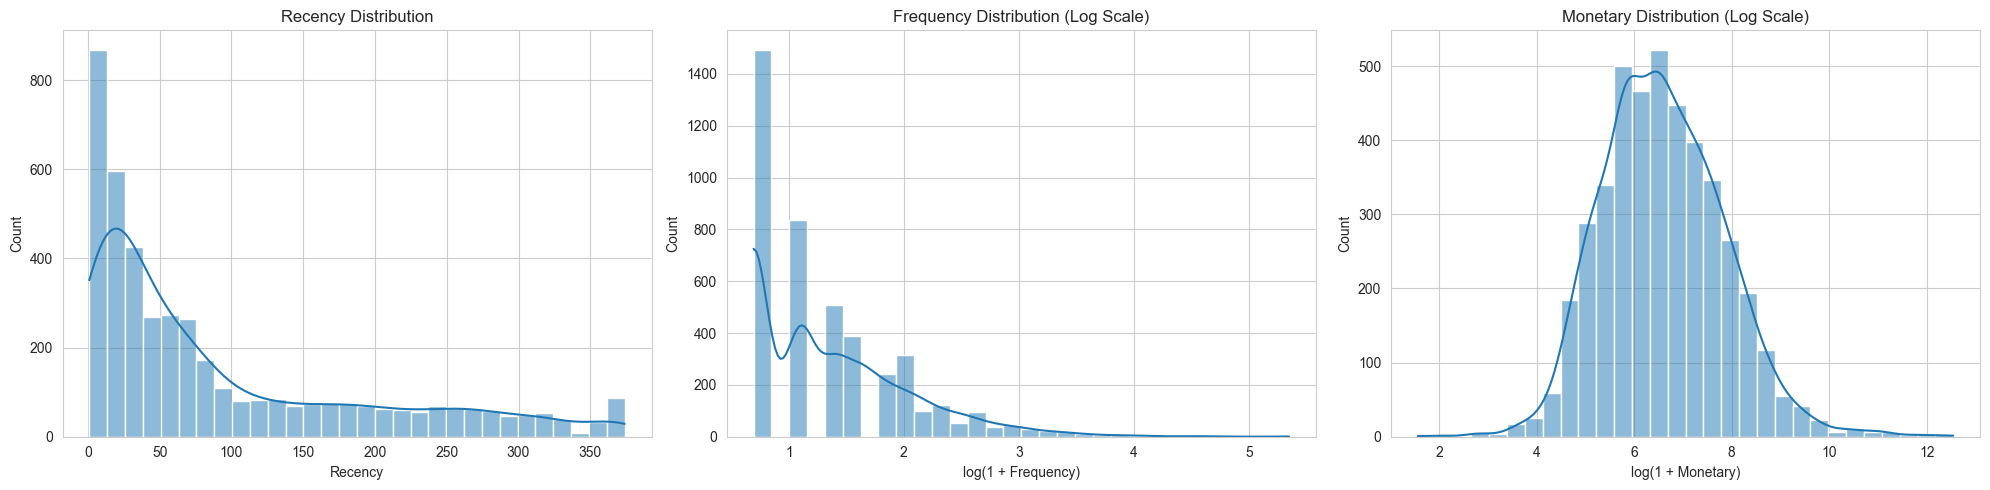

In [58]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.histplot(rfm["Recency"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(np.log1p(rfm["Frequency"]), bins=30, kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution (Log Scale)")
axes[1].set_xlabel("log(1 + Frequency)")

sns.histplot(np.log1p(rfm["Monetary"]), bins=30, kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution (Log Scale)")
axes[2].set_xlabel("log(1 + Monetary)")

plt.tight_layout()
plt.show()

# Recency değişkeni müşterilerin son alışveriş tarihlerini temsil ederken, Frequency ve Monetary değişkenlerinde yüksek derecede sağa çarpık dağılım gözlenmiştir. 
# Bu nedenle görselleştirme aşamasında logaritmik dönüşüm uygulanmıştır. Sonuçlar, müşteri kitlesinin büyük bölümünün düşük satın alma sıklığı ve harcama düzeyine sahip olduğunu, 
# buna karşılık az sayıda müşterinin oldukça yüksek satın alma hacmi oluşturduğunu göstermektedir. Bu durum müşteri segmentasyonunun gerekliliğini desteklemektedir.

In [59]:
# RFM Score (1-5 Quantile)RFM 
#Skorlarının Hesaplanması: Her bir müşteri için Recency, Frequency ve Monetary skorları hesaplanır. 
#Bu skorlar genellikle 1 ila 5 arasında bir ölçekte olabilir. Örneğin, 5 en iyi (yani, en yeni, en sık ve en yüksek tutarda) müşteriyi temsil ederken, 1 en kötü müşteriyi temsil eder.

rfm["R_Score"] = pd.qcut(rfm["Recency"], q=5,labels=[5, 4, 3, 2, 1]).astype(int) #Recency score

rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"),q=5,labels=[1, 2, 3, 4, 5]).astype(int) #Frequency score

rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"), q=5,labels=[1, 2, 3, 4, 5]).astype(int) #Monetary score

# Birleşik RFM skoru (Örn: 555, 344, 125)
rfm["RFM_Score"] = ( rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str)+ rfm["M_Score"].astype(str))

# Toplam RFM skoru (3-15 arası)
rfm["RFM_Total"] = (rfm["R_Score"]+ rfm["F_Score"]+ rfm["M_Score"]) # Müşteri değerini ölçmek için

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,12346.0,326,1,77183.60,1,1,5,115,7
1,12347.0,2,7,4310.00,5,5,5,555,15
2,12348.0,75,4,1797.24,2,4,4,244,10
3,12349.0,19,1,1757.55,4,1,4,414,9
4,12350.0,310,1,334.40,1,1,2,112,4


- RFM Skorlama Sonuçları

RFM analizi kapsamında müşteriler Recency (Son Satın Alma Zamanı), Frequency (Satın Alma Sıklığı) ve Monetary (Toplam Harcama Tutarı) kriterlerine göre 1 ile 5 arasında puanlandırılmıştır. Bu puanlamada 5 en değerli, 1 ise en düşük değere sahip müşteri davranışını temsil etmektedir.

Elde edilen sonuçlar incelendiğinde, örneğin 12347 numaralı müşteri tüm kriterlerde en yüksek puanı (555) alarak en değerli müşteri segmentinde yer almıştır. Buna karşılık 12350 numaralı müşteri, düşük satın alma sıklığı ve düşük harcama tutarı nedeniyle 112 RFM skoruna sahip olup düşük değerli müşteri grubunda bulunmaktadır.

Oluşturulan RFM_Score değişkeni müşterilerin davranışsal özelliklerini üç boyutta özetlerken, RFM_Total değişkeni müşterilerin genel değer seviyesini göstermektedir. Toplam skorlar 3 ile 15 arasında değişmekte olup, yüksek puanlı müşteriler işletme açısından daha değerli ve sadık müşteri profillerini temsil etmektedir.

Bu skorlar sonraki aşamada müşterilerin Champions, Loyal Customers, Potential Loyalists, At Risk ve Lost Customers gibi segmentlere ayrılmasında kullanılmıştır. Böylece her müşteri grubuna yönelik farklı pazarlama ve müşteri ilişkileri stratejileri geliştirilebilecektir.

In [61]:
# RF Score oluştur
rfm["RF_SCORE"] = (rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str))  # Segment oluşturmak için
#Klasik RFM segmentasyonunda segmentler genellikle sadece Recency + Frequency ile oluşturulur

# Basitleştirilmiş Segment Haritası
seg_map = {
            r"5[4-5]": "Champions", #Şampiyonlar
        
            r"[3-4][4-5]": "Loyal Customers", #Sadık Müşteriler
        
            r"51": "New Customers", #Yeni Müşteriler
        
            r"[4-5][2-3]": "Potential Loyalists", #Potansiyel Sadık Müşteriler
        
            r"[1-2][3-5]": "At Risk", # Risk Altında olanlar
        
            r"[1-2][1-2]": "Lost Customers" # Kayıp Müşteriler 
    }

# Segment atama
rfm["Segment"] = (rfm["RF_SCORE"].replace(seg_map, regex=True))

# Eşleşmeyenleri Others yap
valid_segments = [ "Champions","Loyal Customers", "New Customers", "Potential Loyalists", "At Risk","Lost Customers"]

rfm.loc[ ~rfm["Segment"].isin(valid_segments),"Segment"] = "Potential Loyalists"

# Sonuçlar
print(rfm["Segment"].value_counts())

Segment
Potential Loyalists    1128
Lost Customers         1065
Loyal Customers         827
At Risk                 643
Champions               633
New Customers            42
Name: count, dtype: int64


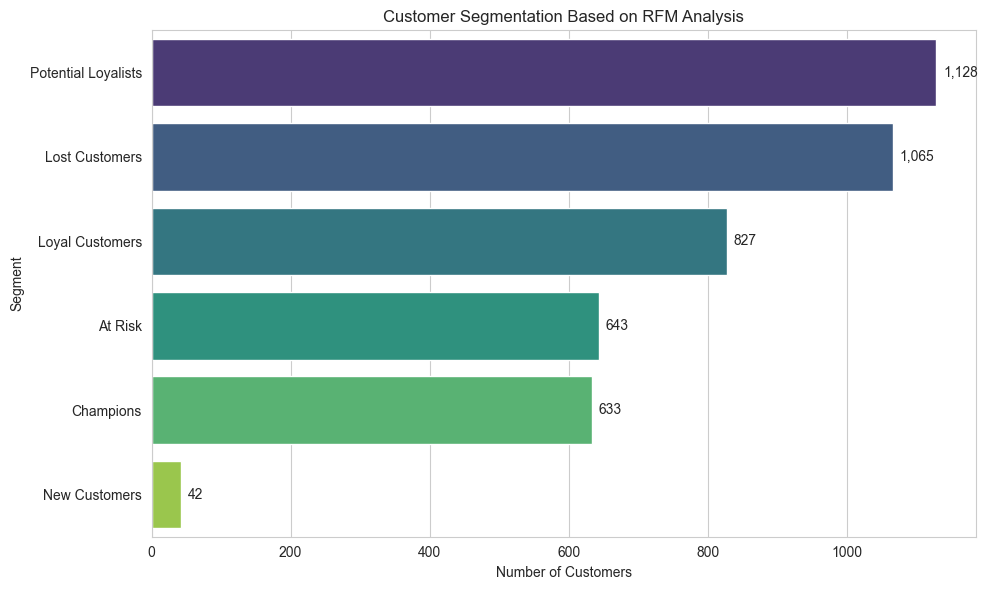

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

segment_counts = ( rfm["Segment"] .value_counts().sort_values(ascending=False))

plt.figure(figsize=(10,6))

ax = sns.barplot( x=segment_counts.values, y=segment_counts.index,  palette="viridis")

for i, v in enumerate(segment_counts.values):
    ax.text(v + 10, i, f"{v:,}", va="center")

plt.title("Customer Segmentation Based on RFM Analysis")
plt.xlabel("Number of Customers")
plt.ylabel("Segment")

plt.tight_layout()
plt.show()

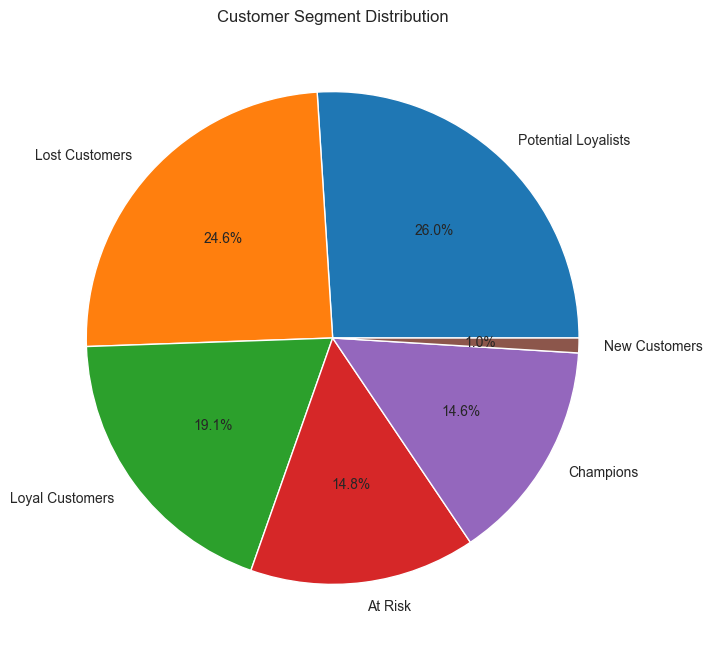

In [63]:
plt.figure(figsize=(8,8))

rfm["Segment"].value_counts().plot( kind="pie", autopct="%1.1f%%", ylabel="")

plt.title("Customer Segment Distribution")
plt.show()

RFM analizi sonucunda toplam 4.338 müşteri altı farklı segmente ayrılmıştır. Segment dağılımları müşteri davranışlarının ve müşteri değerlerinin farklılaştığını göstermektedir.

- Potential Loyalists (26.0%)

En büyük müşteri grubunu oluşturmaktadır. Bu müşteriler yakın zamanda alışveriş yapmış ancak henüz yüksek satın alma sıklığına ulaşmamıştır. Uygun pazarlama kampanyaları ve kişiselleştirilmiş teklifler ile sadık müşterilere dönüştürülebilirler.

- Lost Customers (24.6%)

Müşterilerin yaklaşık dörtte biri uzun süredir alışveriş yapmamış ve düşük etkileşim göstermektedir. Bu durum müşteri kaybının önemli bir seviyede olduğunu göstermektedir. Yeniden kazanım kampanyaları uygulanabilir ancak geri dönüş oranının düşük olması beklenmektedir.

- Loyal Customers (19.1%)

Sadık müşteriler işletmenin düzenli gelir kaynağını oluşturmaktadır. Bu müşteri grubunun elde tutulması müşteri yaşam boyu değerinin artırılması açısından kritik öneme sahiptir.

- At Risk (14.8%)

Bu müşteriler geçmişte aktif olmalarına rağmen son dönemde alışveriş davranışlarında azalma göstermiştir. Özel indirimler ve hedefli iletişim çalışmaları ile yeniden aktif hale getirilebilirler.

- Champions (14.6%)

En değerli müşteri segmentidir. Bu müşteriler hem yakın zamanda alışveriş yapmış hem de yüksek satın alma sıklığı göstermiştir. İşletmenin gelirine en yüksek katkıyı sağlayan grup olarak değerlendirilebilir.

- New Customers (1.0%)

Yakın zamanda kazanılmış müşteri kitlesini temsil etmektedir. Sayılarının düşük olması yeni müşteri kazanım faaliyetlerinin artırılabileceğini göstermektedir.

- Genel Değerlendirme

Analiz sonuçları, müşteri tabanının yaklaşık %60'ının (Potential Loyalists, Loyal Customers ve Champions) işletme için önemli değer taşıyan müşteri gruplarından oluştuğunu göstermektedir. Bununla birlikte müşterilerin yaklaşık %40'ının (Lost Customers ve At Risk) kaybedilmiş veya kaybedilme riski altında olması, müşteri elde tutma stratejilerinin geliştirilmesi gerektiğine işaret etmektedir.Bu sonuçlar, işletmenin hem mevcut değerli müşterilerini korumaya hem de risk altındaki müşterileri yeniden kazanmaya yönelik farklı pazarlama stratejileri geliştirmesi gerektiğini göstermektedir.

<Figure size 1000x600 with 0 Axes>

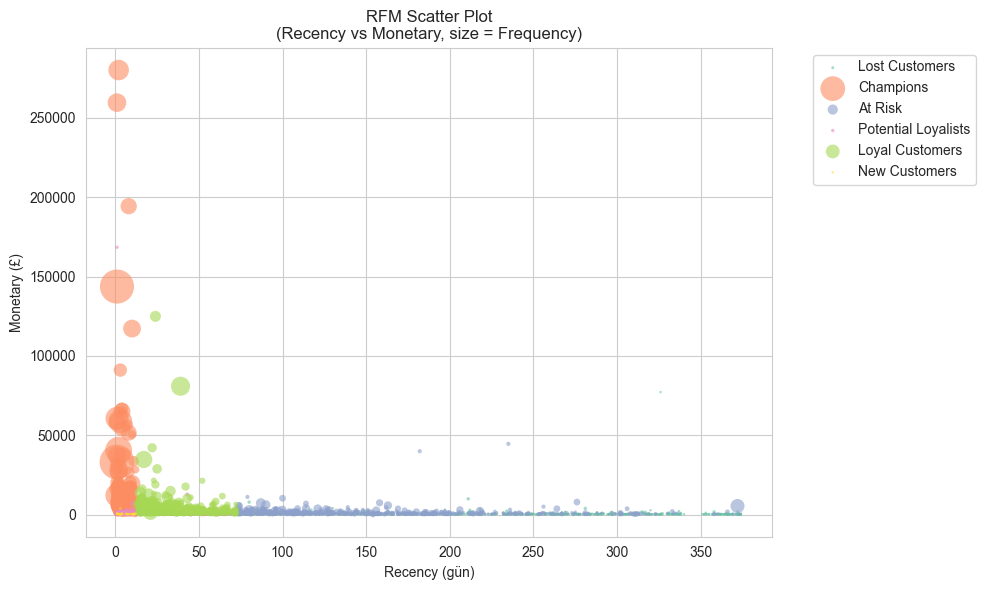

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafik ayarı
plt.figure(figsize=(10, 6))

# Segmentleri al
segments = rfm['Segment'].unique()

# Renk paleti oluştur
palette = dict(zip(segments, sns.color_palette('Set2', len(segments))))

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 6))

for seg in segments:  subset = rfm[rfm['Segment'] == seg]
    
    ax.scatter(
        subset['Recency'],
        subset['Monetary'],
        s=subset['Frequency'] * 3,   # nokta boyutu
        c=[palette[seg]],
        label=seg,
        alpha=0.6,
        edgecolors='none'
    )

# Eksenler ve başlık
ax.set_xlabel('Recency (gün)')
ax.set_ylabel('Monetary (£)')
ax.set_title('RFM Scatter Plot\n(Recency vs Monetary, size = Frequency)')

# Legend dışarı al (daha temiz görünüm)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Düzenleme
plt.tight_layout()
plt.show()

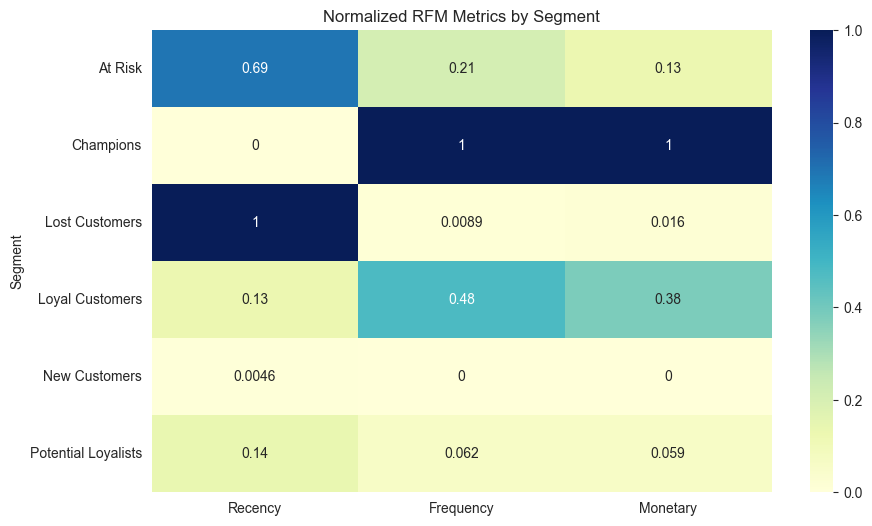

In [65]:
from sklearn.preprocessing import MinMaxScaler

seg_heatmap = (
    rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]]
       .mean()
)

scaler = MinMaxScaler()

seg_heatmap_scaled = pd.DataFrame(
    scaler.fit_transform(seg_heatmap),
    index=seg_heatmap.index,
    columns=seg_heatmap.columns
)

plt.figure(figsize=(10,6))

sns.heatmap(
    seg_heatmap_scaled,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Normalized RFM Metrics by Segment")

plt.show()



- Bu heatmap (ısı haritası), RFM analizi yaptıktan sonra elde ettiğiniz segmentlerin karakteristik özelliklerini anlamak ve bunları iş stratejilerine (aksiyon planlarına) dönüştürmek için kullanılan en efektif yöntemlerden biridir.MinMaxScaler ile değerler 0 ile 1 arasında normalize edilmiştir.

1. Champions (Şampiyonlar) : Şirketin en değerli müşteri kitlesi. Son alışverişlerini çok yakın zamanda yapmışlar (Recency: 0), alışveriş sıklıkları (Frequency: 1) ve
toplam harcamaları (Monetary: 1) zirvede.Aksiyon Planı: Bu segmenti ödüllendirin. Sadakat programları, özel hissettirecek VIP öncelikler veya yeni ürün lansmanlarında erken erişim hakları sunun.

 2. Loyal Customers (Sadık Müşteriler) : Profil: Recency: 0.13, Frequency: 0.48, Monetary: 0.38. Şampiyonların bir tık altı. Nispeten yakın zamanda alışveriş yapmışlar (0.13), satın alma sıklıkları ve harcamaları ortalamanın oldukça üzerinde, gayet iyi durumda.Aksiyon Planı: Bu grubu "Champions" segmentine dönüştürmeye çalışın. Yan ürün önerme (Cross-selling) ve sepet büyütme (Up-selling) stratejileri uygulayarak harcama tutarlarını (Monetary) yukarı çekebilirsiniz.

 3. At Risk (Risk Grubundakiler): Profil: Recency: 0.69, Frequency: 0.21, Monetary: 0.13. Eskiden görece iyi alışveriş yapan, ancak son zamanlarda uğramayan müşteriler. Recency değeri 0.69 ile oldukça yükselmiş. Eğer müdahale edilmezse tamamen kaybedilecekler.Aksiyon Planı: "Sizi Özledik" temalı kişiselleştirilmiş e-postalar gönderin. Geri dönmelerini teşvik edecek, sadece onlara özel ve sınırlı süreli (FOMO etkisi yaratan) ciddi indirim kuponları tanımlayın.

4. Lost Customers (Kaybedilen Müşteriler): Profil: Recency: 1, Frequency: ~0.01, Monetary: ~0.02. En son alışverişlerinin üzerinden en uzun süre geçen (Recency: 1) kitle burası. Alışveriş sıklıkları ve harcamaları da neredeyse sıfıra yakın. Muhtemelen markanızı tamamen terk ettiler.Aksiyon Planı: Bu grubu geri kazanmak için çok yüksek pazarlama bütçeleri harcamak mantıklı olmayabilir (ROI - Yatırım Getirisi düşük olur). Standart, maliyetsiz otomatik bülten listelerinde tutulabilirler ancak agresif kampanya önceliğiniz olmamalıdır.

5. New Customers (Yeni Müşteriler): Profil: Recency: 0.0046 (Neredeyse 0), Frequency: 0, Monetary: 0. Henüz sisteme çok yeni giriş yapmış müşteriler. Recency skorları harika (sıfıra çok yakın, yani dün/bugün alışveriş yapmışlar). Ancak tek bir işlem yaptıkları için henüz Frequency ve Monetary değerleri tabanda (0).Aksiyon Planı: İlk izlenim çok önemlidir. Müşteriye "Hoş Geldiniz" serisi e-postaları atın, markayı tanıtan içerikler sunun ve ikinci alışverişlerini tetikleyecek küçük bir "ikinci alışverişe özel indirim" fırsatı sunarak onları elde tutmaya çalışın.

6. Potential Loyalists (Potansiyel Sadıklar) : Profil: Recency: 0.14, Frequency: 0.062, Monetary: 0.059. Yakın zamanda alışveriş yapmışlar (0.14), frekans ve harcamaları yeni müşterilere göre bir tık daha kıpırdamış durumda. Sadık müşteri olma yolundalar ancak henüz tam olarak bağlanmamışlar.Aksiyon Planı: Bu kitleyi içeride tutmak için abonelik sistemleri, üyelik puanları veya "3 al 2 öde" gibi tekrar alışveriş yapmayı (Frekansı) artıracak oyunlaştırma (gamification) stratejileri uygulayabilirsiniz.

# Kmeans

In [67]:
#Log dönüşümü 
import numpy as np

rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()

rfm_log = np.log1p(rfm_log)  # tek satırda tüm değişkenler

#Standard Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print("Ölçeklenmiş veri istatistikleri:")
rfm_scaled.describe().round(2)

Ölçeklenmiş veri istatistikleri:


,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-2.34,-0.96,-4.00
25%,-0.66,-0.96,-0.68
50%,0.09,-0.36,-0.07
75%,0.84,0.65,0.66
max,1.56,5.86,4.73


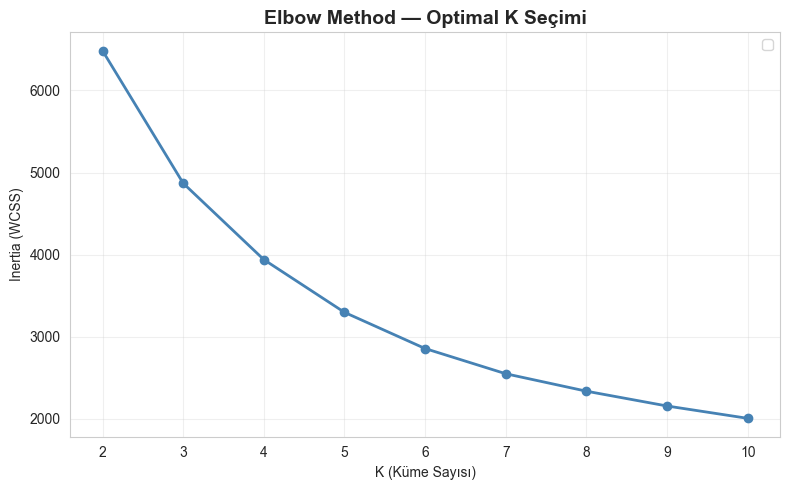

In [71]:
# Elbow Method (K seçimi)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Küme sayıları
K_range = range(2, 11)

# WCSS (inertia) listesi
inertia = [] #Y eksenindeki Inertia (WCSS - Within-Cluster Sum of Squares), küme merkezlerinin o kümedeki noktalara olan uzaklıklarının kareleri toplamıdır.

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Grafik
plt.figure(figsize=(8,5))

plt.plot( K_range, inertia, marker='o', linewidth=2,color='steelblue')

plt.title("Elbow Method — Optimal K Seçimi", fontsize=14, fontweight="bold")
plt.xlabel("K (Küme Sayısı)")
plt.ylabel("Inertia (WCSS)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


- Bu grafik, K-Means algoritmasında veriyi en doğru kaç kümeye ayırmamız gerektiğini (Optimal K Değeri) belirlemek için kullandığımız Elbow Method (Dirsek Yöntemi) çıktısıdır. K (küme sayısı) arttıkça, noktalar küme merkezlerine daha yakın olacağı için Inertia doğal olarak düşer.Nitekim grafikte $K=1$ iken Inertia yaklaşık 13000 seviyelerindeyken,  $K=10$ olduğunda 2000'e kadar gerilemiştir .Amacımız, Inertia'daki düşüşün gözle görülür şekilde yavaşladığı, yani grafiğin bir "dirsek" oluşturduğu kırılma noktasini bulmaktır.
  
- Grafiğinizi incelediğimizde iki temel kırılma (dirsek) noktası dikkat çekiyor:

- K = 2 Noktası: Grafikteki en keskin ve radikal kırılma K=2 noktasında gerçekleşiyor. Inertia neredeyse yarı yarıya düşüyor. Ancak bir e-ticaret veri setinde tüm müşteri portföyünü sadece 2 gruba (Örn: İyi müşteriler - Kötü müşteriler) ayırmak ticari strateji ve aksiyon alabilmek adına çok genel ve sığ kalabilir.

- K = 3 Noktası: Grafikteki ikinci net kırılma ve düzleşme eğiliminin başladığı yer K=3 noktasıdır. K=3'ten sonra çizginin eğimi (aşağı iniş hızı) belirgin bir şekilde azalıyor ve daha doğrusal, yumuşak bir eğriyle devam ediyor.

- Bu grafiğe göre seçilmesi gereken en ideal küme sayısı K = 3'tür. Eğer iş birimi (pazarlama ekibi) sizden biraz daha detaylı bir segmentasyon isterse, eğrinin iyice yataylaşmaya başladığı K = 4 seçeneği de bir alternatif olarak değerlendirilebilir.


In [73]:
from sklearn.preprocessing import StandardScaler

X = rfm[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

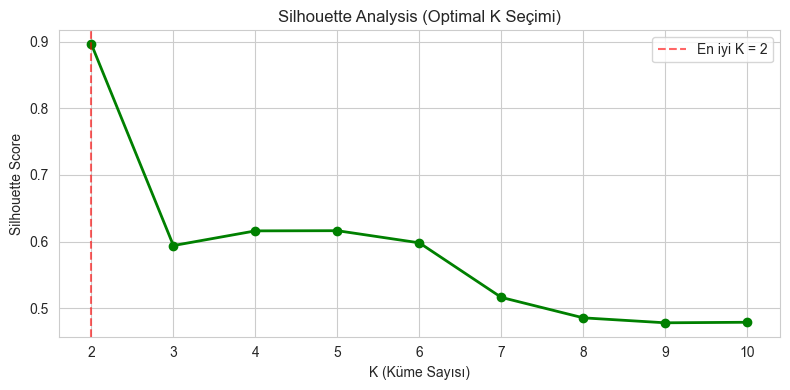

In [74]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

#K aralığını tanımlanır
K_range = range(2, 11)  # 2–10 arası (silhouette için 1 olmaz!) 

 #Silhouette Score hesaplanır
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

# Silhouette grafiği
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(K_range, sil_scores, 'go-', linewidth=2)

ax.set_xlabel('K (Küme Sayısı)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Analysis (Optimal K Seçimi)')

# En iyi K
best_k = list(K_range)[np.argmax(sil_scores)]
ax.axvline( x=best_k, color='red', linestyle='--', alpha=0.6, label=f'En iyi K = {best_k}')

ax.legend()
plt.tight_layout()
plt.show()
#Bu grafik, bir önceki adımdaki Elbow grafiğinin görsel yorumunu netleştiren ve kümelerin kalitesini ölçen en güçlü metriktir.
# Bir veri bilimci olarak bu aşamada karar verirken hem Elbow hem de Silhouette grafiklerini birleştirerek bir yorum yapmalısınız:
# Eğer K=3 seçerseniz: Elbow grafiğinde tam bir dirsek noktasıydı. Silhouette grafiğinde de kararlı bir platoda yer alıyor. 
# Müşterilerinizi kabaca "Düşük", "Orta", "Yüksek" değerlikli gruplar olarak segment etmek istenirse en dengeli yoldur.
# Eğer K=4 veya K=5 seçerseniz: Silhouette skoru K=3 ile neredeyse tamamen aynı kalitede olduğu için matematiksel olarak hiçbir şey kaybedilmez
# Üstelik pazarlama ekibine 4 ya da 5 farklı esnek müşteri segmenti sunmuş oluruz.(Örn: Yıldızlar, Sadıklar, Yeni Gelişenler, Risktekiler).

In [76]:
# Final K seçimi

# Elbow + Silhouette sonucuna göre belirlenir
optimal_K = 4  # genelde 4 veya 5 çıkar

# K-Means modeli ve cluster atama
from sklearn.cluster import KMeans

kmeans_final = KMeans( n_clusters=optimal_K, random_state=42, n_init=10)

rfm['Cluster'] = kmeans_final.fit_predict(X_scaled)

#rfm kullanma nedenimiz: Çünkü clustering işlemi müşteri bazlı yapılır, transaction (satır) bazlı değil.

In [79]:
cluster_profile = (
    rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']] .mean() .round(2))

cluster_profile["Customer_Count"] = rfm["Cluster"].value_counts()
cluster_profile["Customer_Percent"] = (rfm["Cluster"].value_counts(normalize=True) * 100).round(2)

print("Cluster Profilleri:")
cluster_profile.sort_values("Monetary", ascending=False)

Cluster Profilleri:


,Recency,Frequency,Monetary,Customer_Count,Customer_Percent
Cluster,,,,,
2,7.38,82.54,127187.96,13,0.3
3,15.50,22.33,12690.50,204,4.7
0,43.70,3.68,1353.63,3054,70.4
1,248.08,1.55,478.85,1067,24.6


- K-Means algoritması RFM değişkenleri üzerinde uygulandığında dört farklı müşteri segmenti ortaya çıkmıştır. Analiz sonuçlarına göre:
    
    - Cluster 2 , en değerli segment olup  toplam müşteri kitlesinin yalnızca %0.3’ünü oluşturmasına rağmen en yüksek gelir ve işlem yoğunluğuna sahip müşteri grubunu temsil etmektedir.VIP (En Değerli Müşteriler)↔ CRM karşılığı:Champions . Cluster 2 çok küçük olmasına rağmen toplam değerin en büyük kısmını üretmektedir. Bu grup korunması gereken kritik müşteri kitlesidir.
    - Cluster 0 ise %70.4 ile en büyük müşteri segmenti olup düşük frekans ve düşük harcama düzeyiyle potansiyel müşteri kitlesini oluşturmaktadır. Potential (Potansiyel Müşteriler)↔ En yakın CRM segmentleri:Potential Loyalists / New Customers. Cluster 0  en büyük müşteri grubudur ve doğru stratejilerle yüksek değere dönüştürülebilir.
    - Cluster 1, uzun süredir aktif olmayan ve yeniden kazanılması gereken kayıp müşterileri ifade eder.Lost (Kaybedilmiş Müşteriler)↔ CRM karşılığı:Lost Customers. Cluster 1 uzun süredir aktif olmayan müşterilerden oluşur ve yeniden kazanım kampanyaları gerektirir.
    - Cluster 3 düzenli alışveriş yapan ve yüksek değer üreten sadık müşteri grubunu temsil etmektedir.Loyal (Sadık Müşteriler)↔ CRM karşılığı:Loyal Customers.Cluster 3 düzenli alışveriş yapan, istikrarlı gelir sağlayan sadık müşteri tabanını oluşturur.


Bu segmentasyon, gelirin büyük ölçüde küçük bir VIP grup tarafından üretildiğini, müşteri tabanının ise büyük kısmının düşük değerli veya potansiyel segmentte yoğunlaştığını göstermektedir. Bu durum, müşteri tutundurma (retention) ve değer artırma (upsell/cross-sell) stratejilerinin kritik önem taşıdığını ortaya koymaktadır.

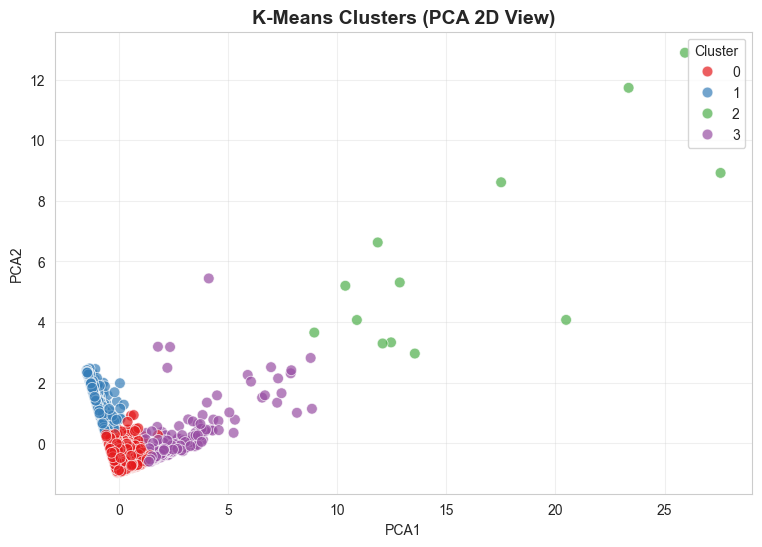

In [87]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------
# 1. PCA ile 2D dönüşüm
# ----------------------------
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

rfm["PCA1"] = pca_result[:, 0]
rfm["PCA2"] = pca_result[:, 1]

# ----------------------------
# 2. PCA Scatter Plot
# ----------------------------
plt.figure(figsize=(9,6))

sns.scatterplot(data=rfm,x="PCA1",y="PCA2",  hue="Cluster", palette="Set1", s=60, alpha=0.7)

plt.title("K-Means Clusters (PCA 2D View)", fontsize=14, fontweight="bold")
plt.legend(title="Cluster")
plt.grid(alpha=0.3)
plt.show()

# Ayrışma Başarısı: PCA görselleştirmesi, kurduğunuz K-Means modelinin geometrik olarak sınırları çok iyi çizdiğini gösteriyor. 
#Özellikle mavi-kırmızı ve kırmızı-mor arasındaki sınırlar cetvelle çizilmiş gibi net.
#Bu durum, veri ön işleme (StandardScaler) aşamasının kusursuz çalıştığını ve Silhouette skorunuzun neden yüksek çıktığını açıklar.

# Doğrusal Yayılım: Verinin sol alttan sağ üste doğru doğrusal bir hat halinde esnemesi, verideki çarpıklığı (skewness) başarıyla yönettiğinizi ve
# e-ticaretin doğasındaki "az sayıda insan çok para harcar, çok sayıda insan az para harcar" (Pareto İlkesi - %80/%20 kuralı) gerçeğini modelin başarıyla yakaladığını gösteriyor.


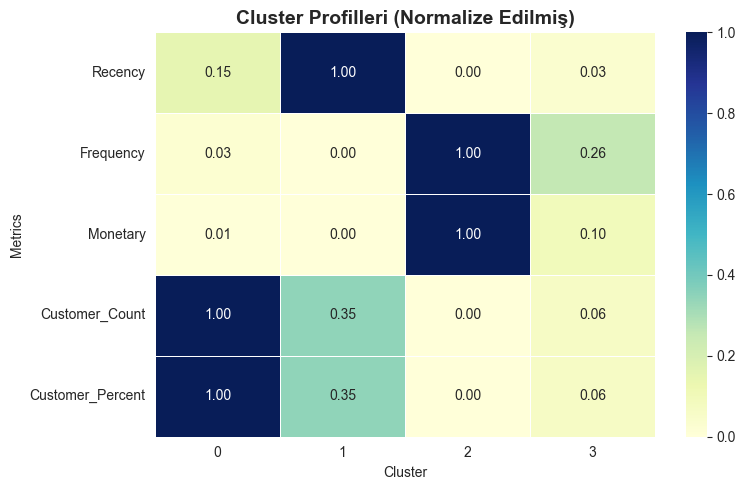

In [82]:
from sklearn.preprocessing import MinMaxScaler

scaled_profile = pd.DataFrame(
    MinMaxScaler().fit_transform(cluster_profile),
    index=cluster_profile.index,
    columns=cluster_profile.columns
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(
    scaled_profile.T,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=ax
)

ax.set_title("Cluster Profilleri (Normalize Edilmiş)", fontsize=14, fontweight="bold")
ax.set_xlabel("Cluster")
ax.set_ylabel("Metrics")

plt.tight_layout()
plt.show()
#K-Means Kararlılığı: Grafiğin satırlarına baktığınızda, her bir cluster'ın kendine has tek bir baskın koyu mavi (1.00) hücresi olduğunu görüyorsunuz
#(Örn: Cluster 1 Recency'de, Cluster 2 Frekans ve Ciroda, Cluster 0 ise Müşteri Hacminde şampiyon). Bu durum, K-Means modelinizin müşterileri birbirinin kopyası olmayan,
# tamamen farklı davranış kalıplarına göre net çizgilerle ayrıştırdığını ispatlar.

# Cohort Analysis

**Cohort Analizi (Cohort Analysis)**

Cohort analizi, belirli zaman dilimlerinde veya davranışsal özelliklere göre gruplandırılmış kullanıcıların davranışlarını incelemek için kullanılan bir analiz yöntemidir. Özellikle müşteri tutma oranlarını ve kullanıcıların zaman içindeki davranışlarını analiz etmek için faydalıdır.

**Cohort Nedir?**
Cohort, belirli bir ortak özelliği paylaşan bir grup insan veya müşteri demektir. Örneğin:
- **Kaydolma tarihi**: Belirli bir ay içinde kaydolmuş kullanıcılar.
- **İlk alışveriş tarihi**: Belirli bir dönemde ilk alışveriş yapan müşteriler.

**Cohort Analizinin Amaçları:**
1. Müşteri tutma oranlarını analiz etmek.
2. Müşteri davranışlarındaki eğilimleri anlamak.
3. Pazarlama stratejilerinin etkinliğini ölçmek.
4. Zaman içinde müşteri gruplarının nasıl değiştiğini görmek.

**Nasıl Yapılır?**
Cohort Analysis genellikle müşterilerin ilk satın alma veya kayıt tarihine dayalı olarak yapılır. Temel adımlar şunlardır:

1. **Cohort Belirleme**: Analize dahil edilecek müşteri gruplarını tanımlayın. Örneğin, müşterileri kayıt tarihlerine göre aylık olarak gruplara ayırabilirsiniz.

2. **Müşteri Davranışlarının İzlenmesi**: Belirlenen her bir cohort için, müşterilerin zaman içindeki davranışlarını (örneğin, satın alma miktarı, tekrar satın alma oranı) izleyin.

3. **Gelişmelerin Analizi**: Her bir cohort için, zamanla değişen davranışları ve performansı analiz edin. Bu, özellikle cohort'un ilk etkileşimden sonraki davranışlarına ve müşteri yaşam döngüsüne odaklanır.

4. **Segmentasyon ve Karşılaştırma**: Elde edilen verileri analiz edin ve farklı cohort gruplarını karşılaştırın. Bu, belirli pazarlama stratejilerinin veya işletme değişikliklerinin cohort gruplarının davranışlarına nasıl etki ettiğini anlamak için önemlidir.

**Cohort Analizinin Kullanım Alanları:**
- **E-Ticaret:** Müşteri sadakatini ve satın alma eğilimlerini ölçmek.
- **SaaS Şirketleri:** Abonelik iptali (churn) oranını analiz etmek.
- **Mobil Uygulamalar:** Kullanıcıların aktif kalma oranlarını görmek.
  
**Cohort Analizinin Faydaları**

- **Müşteri Davranışlarının Anlaşılması**: Hangi müşteri gruplarının işletme için en değerli olduğunu ve nasıl davrandığını anlamak için değerli bir yol sağlar.

- **Pazarlama Stratejilerinin Optimizasyonu**: Cohort Analysis, pazarlama stratejilerinin etkilerini değerlendirmek ve optimize etmek için kullanılabilir.

- **Sadakat ve Müşteri İlişkileri Yönetimi**: Müşteri sadakati ve ilişkilerinin zaman içinde nasıl değiştiğini anlamak için kullanılabilir.

**Örnek Analiz Soruları:**
- Yeni müşteriler ilk alışverişlerinden sonra ne kadar süre bağlı kalıyor?
- Pazarlama kampanyası belirli bir dönemdeki müşterileri nasıl etkiledi?
- Müşteri tutma oranı zamanla artıyor mu, azalıyor mu?

---

**RFM Analizi ve Cohort Analizi Arasındaki Farklar:**
| **RFM Analizi**                         | **Cohort Analizi**                     |
|------------------------------------------|-----------------------------------------|
| Müşterileri bireysel skorlarla değerlendirir. | Müşterileri gruplar halinde inceler.    |
| Daha çok müşteri segmentasyonu için kullanılır. | Müşteri davranışlarını analiz etmek için uygundur. |
| Hedefi, müşterinin güncel ve geçmiş davranışlarını değerlendirmektir. | Zaman içindeki eğilimleri analiz etmeye odaklanır. |

In [89]:
df_cohort = df1.copy()

# 1) Invoice ayı 
df_cohort["InvoiceMonth"] = df_cohort["InvoiceDate"].dt.to_period("M")

# 2) Cohort (ilk satın alma ayı)
df_cohort["CohortMonth"] = df_cohort.groupby("CustomerID")["InvoiceDate"] \
    .transform("min").dt.to_period("M")

# 3) Cohort Index (kaç ay sonra)
df_cohort["CohortIndex"] = (
    (df_cohort["InvoiceMonth"].dt.to_timestamp() -
     df_cohort["CohortMonth"].dt.to_timestamp())
    .dt.days // 30
)

# 4) Kontrol
df_cohort[[ "CustomerID", "CohortMonth", "InvoiceMonth", "CohortIndex"]].head()

#Bu analiz, müşteri sadakatini ölçmek ve kullanıcıların zaman içindeki geri dönüş davranışlarını incelemek için kritik bir adımdır. 
#Cohort yapısı sayesinde hangi dönemlerde kazanılan müşterilerin daha uzun süre aktif kaldığı veya ne kadar hızlı kaybedildiği tespit edilebilir.

,CustomerID,CohortMonth,InvoiceMonth,CohortIndex
0,17850,2010-12,2010-12,0
1,17850,2010-12,2010-12,0
2,17850,2010-12,2010-12,0
3,17850,2010-12,2010-12,0
4,17850,2010-12,2010-12,0


In [94]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Cohort Table (müşteri sayısı)
# ----------------------------
cohort_data = ( df_cohort.groupby(["CohortMonth", "CohortIndex"])["CustomerID"].nunique().reset_index())

cohort_pivot = cohort_data.pivot( index="CohortMonth",columns="CohortIndex",values="CustomerID")

# ----------------------------
# 3. Retention matrix (%)
# ----------------------------
cohort_size = cohort_pivot.iloc[:, 0]

retention = cohort_pivot.divide(cohort_size, axis=0) * 100
retention = retention.round(2)

retention_12 = retention.iloc[-12:, :12]

print("Cohort tablosu:", cohort_pivot.shape)

# Cohort analizi sonucunda 13 farklı müşteri kazanım dönemi ve bu kohortların 13 aylık müşteri davranış takibi elde edilmiştir.
# Bu yapı, müşteri sadakatinin zaman içerisindeki değişimini analiz etmek için yeterli veri derinliğine sahiptir.

Cohort tablosu: (13, 13)


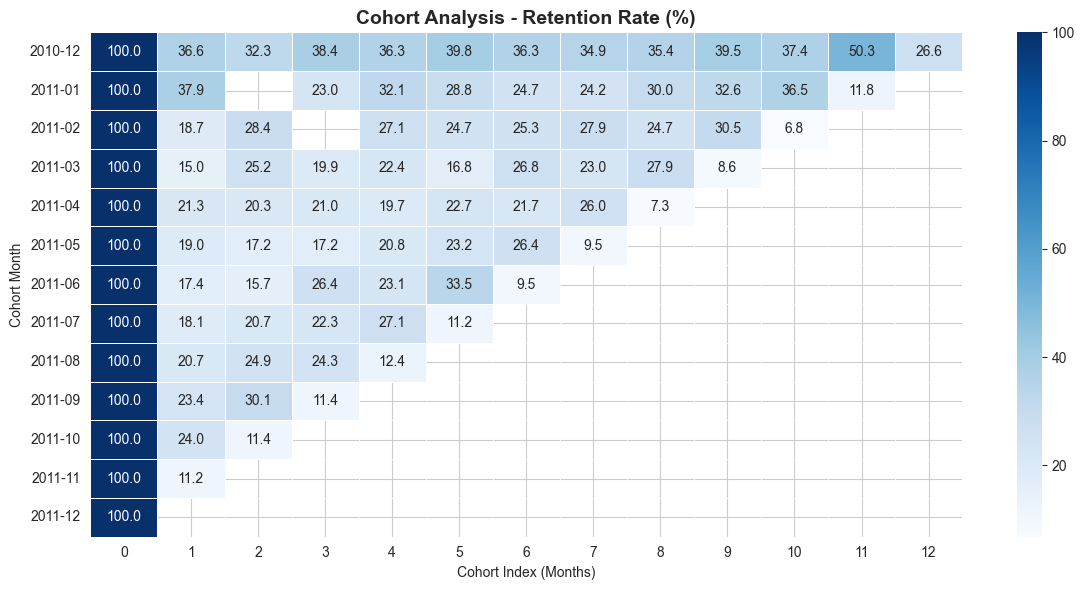

Cohort Pivot Shape: (13, 13)


In [96]:

#  Heatmap (Retention)
# ----------------------------
plt.figure(figsize=(12,6))

sns.heatmap(retention, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)

plt.title("Cohort Analysis - Retention Rate (%)", fontsize=14, fontweight="bold")
plt.xlabel("Cohort Index (Months)")
plt.ylabel("Cohort Month")

plt.tight_layout()
plt.show()


# 5. Tablo çıktısı
# ----------------------------
print("Cohort Pivot Shape:", cohort_pivot.shape)


Cohort Analizi (Müşteri Elde Tutma - Retention) aşamasını da elde edilen bu üçgen matris (heatmap), bir e-ticaret yöneticisinin sitenin genel sağlığını ve müşteri sadakatini ölçmek için bakacağı ilk tablodur.
 - Dikey Eksen (Cohort Month): Müşterilerin sitenizden ilk alışverişlerini yaptıkları ayı gösterir (Yani o ay kazanılan yeni müşteri grubu).

 - Yatay Eksen (Cohort Index): İlk alışverişten sonra geçen ay sayısını ifade eder. 0 numaralı ay, müşterilerin kazanıldığı ilk aydır ve doğal olarak herkes aktif olduğu için değerler %100'dür.
 - Hücrelerdeki Değerler: İlk ay gelen müşterilerin, sonraki aylarda yüzde kaçının siteye geri dönüp tekrar alışveriş yaptığını (Retention Rate) gösterir.
        
- En Başarılı Dönem: Aralık 2010 Cohort'u (2010-12): Analiz: İlk satırı incelediğinde, renklerin diğer aylara göre çok daha koyu mavi ve oranların belirgin şekilde yüksek olduğunu görülür. Aralık 2010'da kazanılan 885 müşterinin %36.6'sı ilk ay geri gelmiş ve bu oran neredeyse 1 yıl boyunca %30 ile %40 arasında inanılmaz kararlı bir şekilde yüksek kalmış.Hatta 11. Ayda (Cohort Index 11) muazzam bir patlama yaşanarak geri dönme oranı %50.3'e fırlamış. İş Dünyasındaki Karşılığı: Aralık ayı yılbaşı, "Black Friday" (Kasım/Aralık geçişi) ve kış sezonu indirimlerinin yoğun olduğu bir dönemdir. Bu dönemde sisteme giren müşteriler hem organik olarak sadık kitleye dönüşmüş hem de tam 1 yıl sonraki bir sonraki yılbaşı/kış sezonunda (Cohort Index 11 - Kasım/Aralık 2011) tekrar çok güçlü bir şekilde alışverişe yönelmişlerdir.

- Dikkat Çeken Düşüş: Şubat ve Mart 2011 Cohort'ları: Analiz: 2011-02 ve 2011-03 satırlarına baktığımızda, 1. ayda (Cohort Index 1) elde tutma oranlarının %18.7 ve %15.0 seviyelerine sert bir şekilde düştüğünü görüyoruz. Yani bu aylarda siteye ilk kez gelen müşterilerin büyük çoğunluğu (%80'den fazlası) sonraki ay siteyi terk etmiş. İş Dünyasındaki Karşılığı: Bahar döneminde yapılan pazarlama kampanyalarının kalitesi düşük kalmış olabilir ya da bu dönemde siteye gelen müşteriler sadece tek seferlik, kalıcı olmayan bir promosyondan ötürü alışveriş yapmış olabilirler.  

-  Genel Trend (Sütun Boyunca "Horizontal" Bakış): Müşteriler ilk ay kazanıldıktan sonra, 1. ayda (Index 1) genel olarak %15 ile %24 arasına sert bir düşüş (Churn - Müşteri Kaybı) yaşanıyor.   Ancak e-ticaret için asıl güzel haber şu: 2. ve 3. aylardan itibaren oranlar dibe çökmüyor, aksine %20 - %25 bandında stabilize oluyor (plato çiziyor). Bu durum, sitenizin çekirdek bir sadık müşteri kitlesi yaratabildiğini ve ürün kalitesi/hizmet memnuniyetinin fena olmadığını gösterir.

Sezonluk Etki Çok Güçlü: Yılın son çeyreğinde (Aralık dönemi) kazanılan müşterilerin yaşam boyu değeri (LTV) ve sadakati, bahar aylarında (Şubat-Mart) kazanılanlara göre yaklaşık 2 kat daha fazladır. Pazarlama bütçesi optimizasyonunda bütçenin büyük kısmı yıl sonu sadakat programlarına aktarılmalıdır.

Kritik Eşik 1. Ay: Müşterilerin en çok kaybedildiği an, ilk alışverişi takip eden ilk 30 gündür (Index 1). Bu yüzden e-ticaret yönetiminin, ilk kez alışveriş yapan kullanıcılara 1. ay dolmadan "ikinci alışveriş teşvik kuponları" tanımlaması kritik bir büyüme (growth hacking) adımı olacaktır.

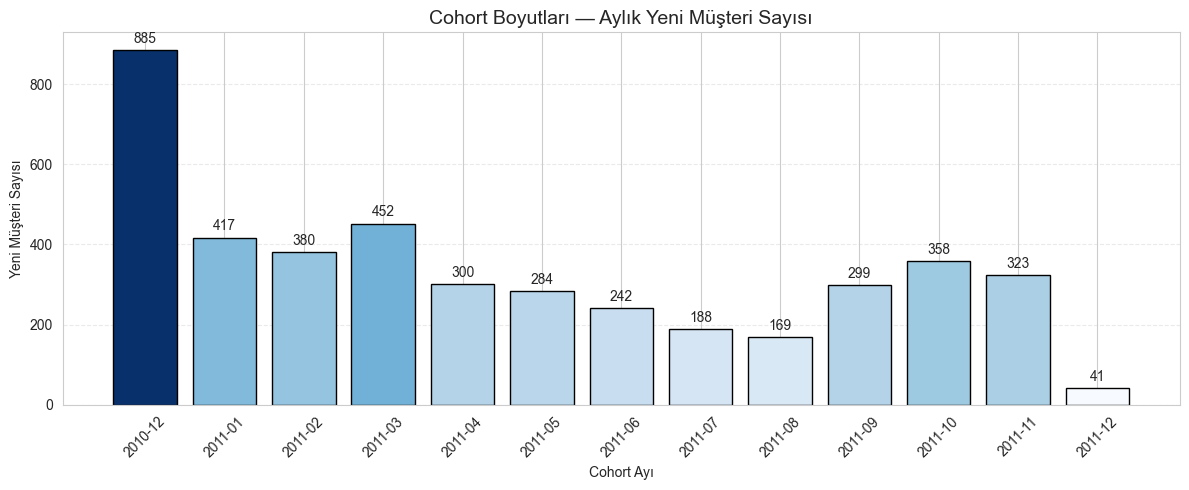

In [100]:
import matplotlib.pyplot as plt
import numpy as np

cohort_size_all = cohort_pivot.iloc[:, 0].sort_index()

fig, ax = plt.subplots(figsize=(12, 5))

norm = plt.Normalize(cohort_size_all.min(), cohort_size_all.max())
colors = plt.cm.Blues(norm(cohort_size_all.values))  # artışa göre koyulaşır

bars = ax.bar(
    cohort_size_all.index.astype(str),
    cohort_size_all.values,
    color=colors,
    edgecolor='black'
)

ax.set_title('Cohort Boyutları — Aylık Yeni Müşteri Sayısı', fontsize=14)
ax.set_xlabel('Cohort Ayı')
ax.set_ylabel('Yeni Müşteri Sayısı')

ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.4)

ax.bar_label(bars, padding=3, fontsize=10)

plt.tight_layout()
plt.show()

#Bu grafik, "Aylık Yeni Müşteri Sayısı" (Cohort Hacimleri) dağılımını göstererek, projenin sonraki aşamalarında yorumlanan "Retention (Elde Tutma)" 
# oranlarının arkasındaki gerçek örneklem büyüklüğünü (insan sayısını) ortaya koymaktadır.

#Maksimum Müşteri Kazanımı (Zirve): Sitenin en yüksek yeni kullanıcı hacmine 885 yeni müşteri ile Aralık 2010 döneminde ulaşıldığı görülmektedir. 
#Bu kitle, sonraki aylarda elde tutma (retention) oranı en yüksek ve marka sadakati en güçlü çıkan "çekirdek" gruptur.

# Yaz Dönemi Durgunluğu (Dip): Ocak 2011 itibarıyla düşüşe geçen yeni müşteri sayıları, e-ticaret sektöründeki dönemsel (sezonsallık) durgunluğun bir sonucu olarak 
# Ağustos 2011'de 169 müşteri ile yılın en düşük seviyesine (dip noktasına) gerilemiştir.

# Son Çeyrekte Yeniden Canlanma: Okula dönüş ve sonbahar/kış sezonu kampanyalarının etkisiyle Eylül (299) ve Ekim (358) aylarında yeni müşteri kazanımında yeniden güçlü bir
# yukarı yönlü ivme yakalanmıştır.

# Aralık 2011 Anomalisi: Grafik sonunda, Aralık 2011'de görünen 41 sayısı ticari bir başarısızlık değil; ham veri setinin bu ayın hemen başında kesilmesinden 
# (tam bir ayı kapsamasından önce tamamlanmasından) kaynaklanan teknik bir kısıttır.

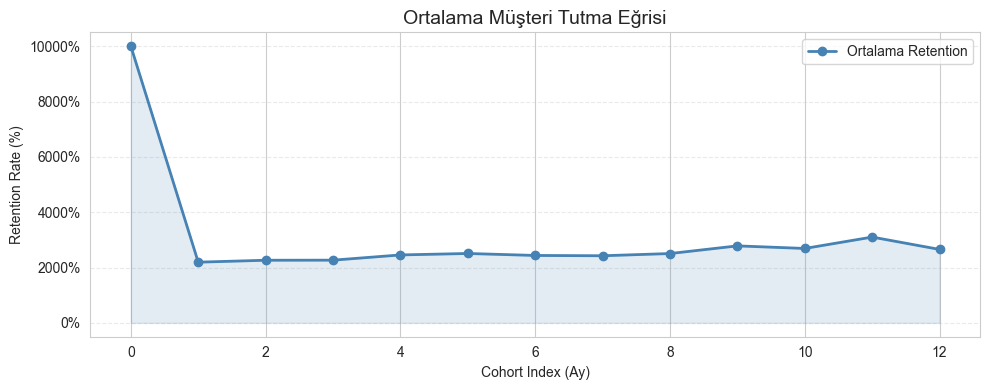

In [102]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

avg_retention = retention.mean(axis=0).dropna().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    avg_retention.index,
    avg_retention.values * 100,   # TEK YERDE yüzde dönüşümü
    marker='o',
    linewidth=2,
    color='steelblue',
    label='Ortalama Retention'
)

ax.fill_between(
    avg_retention.index,
    avg_retention.values * 100,
    alpha=0.15,
    color='steelblue'
)

ax.set_title('Ortalama Müşteri Tutma Eğrisi', fontsize=14)
ax.set_xlabel('Cohort Index (Ay)')
ax.set_ylabel('Retention Rate (%)')

ax.yaxis.set_major_formatter(mticker.PercentFormatter())

ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()

#Bu grafik, platformunuza farklı aylarda katılan tüm müşteri gruplarının (cohort’ların) zaman içindeki ortalama geri dönüş performansını tek bir çizgide birleştiren 
#"Ortalama Müşteri Tutma Eğrisi" (Average Retention Curve) çıktısıdır.

#Ortalama Müşteri Tutma Eğrisi Analiz Raporu
# 1. Ay Kritik Kırılma Eşiği (The Churn Drop): Grafikteki en radikal hareket $0$ ile $1$. aylar arasında gerçekleşmektedir.
# İlk alışverişini yapan müşterilerin yaklaşık %78'i ilk 30 gün içinde sistemi terk etmekte (churn olmakta), ortalama retention seviyesi %22 bandına sert bir düşüş göstermektedir.
# Sadık Plato Dönemi (Stabilization): 1. aydan itibaren 12. aya kadar geçen süreçte eğri aşağı doğru çökmeye devam etmemekte; %22 ile %30 arasında son derece kararlı ve 
# düz bir hat (plato) çizmektedir. Bu durum, ilk ayı atlatan müşterilerin kalıcı birer "Sadık Müşteri" haline geldiğini ve platformun organik bir taban oluşturmayı başardığını gösterir.
# 11. Ay Sezonsallık Pik Noktası (The 11th Month Peak): Eğrinin sonuna doğru, 11. ayda görünür bir yükseliş trendiyle oran %30'un üzerine tırmanmaktadır. 
# Bu durum, sisteme giren müşterilerin tam 1 yıl sonraki dönemsel kampanyalarda (Yılbaşı, Kasım/Aralık indirimleri) yeniden güçlü bir şekilde satın almaya yöneldiğinin kanıtıdır.

In [104]:
def safe_retention(idx):
    return avg_retention.iloc[idx] if len(avg_retention) > idx else None

if safe_retention(1) is not None:
    print(f"Ay 1 Ortalama Retention: %{safe_retention(1):.1f}")

if safe_retention(3) is not None:
    print(f"Ay 3 Ortalama Retention: %{safe_retention(3):.1f}")

Ay 1 Ortalama Retention: %21.9
Ay 3 Ortalama Retention: %22.7


In [107]:
# Segment bazlı özet tablo
summary = (
    rfm.groupby('Segment')
    .agg(
        Müşteri_Sayısı=('CustomerID', 'nunique'),
        Ort_Recency=('Recency', 'mean'),
        Ort_Frequency=('Frequency', 'mean'),
        Ort_Monetary=('Monetary', 'mean')
    )
    .round(1)
    .sort_values('Ort_Monetary', ascending=False)
    .reset_index()
)

print('=== Segment Özet Tablosu ===')

summary_style = (
    summary.style
    .format({
        'Ort_Recency': '{:.1f}',
        'Ort_Frequency': '{:.1f}',
        'Ort_Monetary': '{:.1f}'
    })
    .bar(subset=['Ort_Monetary'], color='steelblue')
)

summary_style

=== Segment Özet Tablosu ===


,Segment,Müşteri_Sayısı,Ort_Recency,Ort_Frequency,Ort_Monetary
0,Champions,633,5.9,12.4,6843.2
1,Loyal Customers,827,33.5,6.5,2848.3
2,At Risk,643,152.8,3.4,1241.1
3,Potential Loyalists,1128,34.9,1.7,768.9
4,Lost Customers,1065,217.9,1.1,486.7
5,New Customers,42,6.9,1.0,385.0


RFM Segment Özet Raporu
Tablo, platformdaki müşterilerin satın alma yeniliği (Recency), sıklığı (Frequency) ve bıraktıkları toplam ciroya (Monetary) göre 6 stratejik segmente ayrılmış dağılımını göstermektedir:

- Champions (Şampiyonlar - 633 Kişi): Sitenin finansal motorudur. Ortalama 5.9 gün gibi çok yakın bir zamanda alışveriş yapmışlardır, satın alma sıklıkları 12.4 ile en yüksek gruptur ve kişi başı ortalama 6,843.2 £ ciro bırakarak şirkete en yüksek katma değeri sağlarlar.

- Loyal Customers (Sadık Müşteriler - 827 Kişi): Şampiyonların ardından gelen en dengeli gruptur. Ortalama 33.5 gün önce işlem yapmış, 6.5 frekans ve 2,848.3 £ ortalama harcama ile stabil bir gelir akışı sağlarlar.

- Potential Loyalists (Potansiyel Sadıklar - 1,128 Kişi): Müşteri sayısı bakımından en kalabalık gruptur. Yenilik süreçleri sadık müşteriler kadar iyidir (34.9 gün), ancak sıklıkları (1.7) ve sepet büyüklükleri (768.9 £) henüz düşüktür. Doğru kampanyalarla üst segmentlere taşınmaya en müsait kitledir.

-At Risk (Risk Altındakiler - 643 Kişi) & Lost Customers (Kaybedilenler - 1,065 Kişi): Platformun acil aksiyon alması gereken finansal kaçak noktasıdır. "At Risk" grubu geçmişte iyi harcama yapmasına rağmen ortalama 152.8 gündür siteye uğramamıştır. "Lost Customers" ise 217.9 gündür tamamen inaktiftir ve kalıcı olarak kaybedilmek üzeredir.

-New Customers (Yeni Müşteriler - 42 Kişi): Ortalama 6.9 gün önce ilk alışverişini yaparak sisteme yeni dahil olmuş, frekansı henüz 1 olan ve büyüme eğrisinin en başında yer alan taze kitledir.

1.128 kişiyle hacimsel olarak zirvede olan "Potential Loyalists" grubu, e-ticaret platformunun en büyük büyüme fırsatıdır. Bu kitleye yönelik frekans artırıcı (sadakat programları, puan sistemleri) stratejiler geliştirilerek harcama tutarları yukarı çekilmelidir. Ayrıca, "At Risk" grubunun ortalama harcaması (1,241.1 £) yüksek olduğu için, bu kitleyi geri kazanmaya yönelik acil ve özel re-aktivasyon kuponları tanımlanmalıdır.